In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import VarianceThreshold, f_classif, SelectKBest
from sklearn.metrics import classification_report, confusion_matrix,r2_score, explained_variance_score, mean_absolute_error, mean_squared_error,roc_auc_score,accuracy_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from feature_engine.encoding import OneHotEncoder, OrdinalEncoder

from xgboost import XGBClassifier

2026-05-23 22:24:47.760444: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
#models results
train_roc_auc = dict()
test_roc_auc = dict()
best_accuracy_with_best_parameters = dict()

# function with different metrics to evaluate train model
def evaluating_the_train_model(y_train, y_predict_train):
    
    print('Classification report train set')
    print(classification_report(y_train, y_predict_train))
    print()
    
    print('r2 squared error train set:',r2_score(y_train, y_predict_train))
    print('explained variance score train set:',explained_variance_score(y_train, y_predict_train))
    print('mean absolute error train set:',mean_absolute_error(y_train, y_predict_train))
    print('mean squared error  train set:',mean_squared_error(y_train, y_predict_train))
    print('roc-auc score: {}'.format(roc_auc_score(y_train, y_predict_train)))
    print()
    
    print('Confusion matrix train set')
    cm = confusion_matrix(y_train, y_predict_train)
    sns.heatmap(cm, annot = True)
    
    
# function with different metrics to evaluate test model    
def evaluating_the_test_model(y_test, y_predict_test):
    
    print('Classification report test set')
    print(classification_report(y_test, y_predict_test))
    print()
    
    print('r2 squared error test set:',r2_score(y_test, y_predict_test))
    print('explained variance score test set:',explained_variance_score(y_test, y_predict_test))
    print('mean absolute error test set:',mean_absolute_error(y_test, y_predict_test))
    print('mean squared error test set:',mean_squared_error(y_test, y_predict_test))
    print('roc-auc score: {}'.format(roc_auc_score(y_test, y_predict_test)))
    print()
    
    print('Confusion matrix test set')
    cm = confusion_matrix(y_test, y_predict_test)
    sns.heatmap(cm, annot = True)
    

#predicting model and evaluating it with metrics
def metrics_of_predicted_models(X_train, X_test, y_train, y_test,classifier,name_of_the_model):
    
    y_predict_train = classifier.predict(X_train)
    y_predict_test = classifier.predict(X_test)
    print(name_of_the_model)
    print('Train set')
    evaluating_the_train_model(y_train, y_predict_train)
    pred = classifier.predict_proba(X_train)
    train_roc_auc_proba = roc_auc_score(y_train,pred[:,1])
    print(name_of_the_model+ ' train roc-auc with predict_proba: {}'.format(train_roc_auc_proba))
    print()
    
    print('Test set')
    evaluating_the_test_model(y_test, y_predict_test)
    pred = classifier.predict_proba(X_test)
    test_roc_auc_proba = roc_auc_score(y_test,pred[:,1])
    print(name_of_the_model+ ' test roc-auc with predict_proba: {}'.format(test_roc_auc_proba))
    print()
    
    train_roc_auc[name_of_the_model] = train_roc_auc_proba
    test_roc_auc[name_of_the_model] = test_roc_auc_proba

#looking for the best parameters with grid search
def grid_search_best_parameters(classifier, parameters, X_train, y_train,name_of_the_model):
     
    grid_search = GridSearchCV(
            estimator = classifier, 
            param_grid = parameters,
            scoring = 'accuracy',
            cv = 10,
            n_jobs = -1)

    grid_search.fit(X_train, y_train)

    best_accuracy = grid_search.best_score_
    best_parameters = grid_search.best_params_

    print("Best accuracy: {:2f} %".format(best_accuracy * 100))
    print("Best parameters: ", best_parameters)
    print()

    model = grid_search.best_estimator_
    
    best_accuracy_with_best_parameters[name_of_the_model] = best_accuracy * 100


In [3]:
employee_df = pd.read_csv('../human_resources/Human_Resources.csv')
employee_df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [4]:
#checking features information and also checking null values
employee_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [5]:
#we can see that there is no Null values

In [6]:
#checking description of every feature
employee_df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


# Feature Descriotion

### Age- age of employee min 18 and max 60
### DailyRate - amount of daily wage min 102 and max 1499
### DistanceFromHome - min 1 and max 29
### Education - level of education min 1 and max 5. 
        #### My guesses
        #### 5 Phd 
        #### 4 Master's 
        #### 3 Bachelor's 
        #### 2 Associate
        #### 1 High school
        
### EmployeeCount ???
### EmployeeNumber ???
### EnvironmentSatisfaction - from min 1 to max 4
### HourlyRate - salary per hour from min 30 to max 100
### JobInvolvement - from min 1 to max 4
### JobLevel ??? from min 1 to max 5
### RelationshipSatisfaction - guess its level of satisfaction with relationshops with colleagues from min 1 to max 4

### StandardHours - min and max is 80 hours(ПОСТОЯННАЯ??? одно значение везде)
### StockOptionLevel - Employee stock options are offered by companies to their employees from 0 to 3
### TotalWorkingYears - from 0 to 40
### TrainingTimesLastYear

In [7]:
employee_df.nunique() #checking amount of unique values in every feature

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

In [8]:
for var in employee_df.columns:
    print (var, employee_df[var].unique()[0:10], '\n') #unique values

Age [41 49 37 33 27 32 59 30 38 36] 

Attrition ['Yes' 'No'] 

BusinessTravel ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel'] 

DailyRate [1102  279 1373 1392  591 1005 1324 1358  216 1299] 

Department ['Sales' 'Research & Development' 'Human Resources'] 

DistanceFromHome [ 1  8  2  3 24 23 27 16 15 26] 

Education [2 1 4 3 5] 

EducationField ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree'
 'Human Resources'] 

EmployeeCount [1] 

EmployeeNumber [ 1  2  4  5  7  8 10 11 12 13] 

EnvironmentSatisfaction [2 3 4 1] 

Gender ['Female' 'Male'] 

HourlyRate [94 61 92 56 40 79 81 67 44 84] 

JobInvolvement [3 2 4 1] 

JobLevel [2 1 3 4 5] 

JobRole ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative' 'Manager'
 'Sales Representative' 'Research Director' 'Human Resources'] 

JobSatisfaction [4 2 3 1] 

MaritalStatus ['Single' 'Married' 'Divorced'] 

MonthlyIncome [5993 5130 2090 2909 3468 3068 2670 2693 95

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'DailyRate'}>,
        <Axes: title={'center': 'DistanceFromHome'}>,
        <Axes: title={'center': 'Education'}>,
        <Axes: title={'center': 'EmployeeCount'}>],
       [<Axes: title={'center': 'EmployeeNumber'}>,
        <Axes: title={'center': 'EnvironmentSatisfaction'}>,
        <Axes: title={'center': 'HourlyRate'}>,
        <Axes: title={'center': 'JobInvolvement'}>,
        <Axes: title={'center': 'JobLevel'}>],
       [<Axes: title={'center': 'JobSatisfaction'}>,
        <Axes: title={'center': 'MonthlyIncome'}>,
        <Axes: title={'center': 'MonthlyRate'}>,
        <Axes: title={'center': 'NumCompaniesWorked'}>,
        <Axes: title={'center': 'PercentSalaryHike'}>],
       [<Axes: title={'center': 'PerformanceRating'}>,
        <Axes: title={'center': 'RelationshipSatisfaction'}>,
        <Axes: title={'center': 'StandardHours'}>,
        <Axes: title={'center': 'StockOptionLevel'}>,
        <Axe

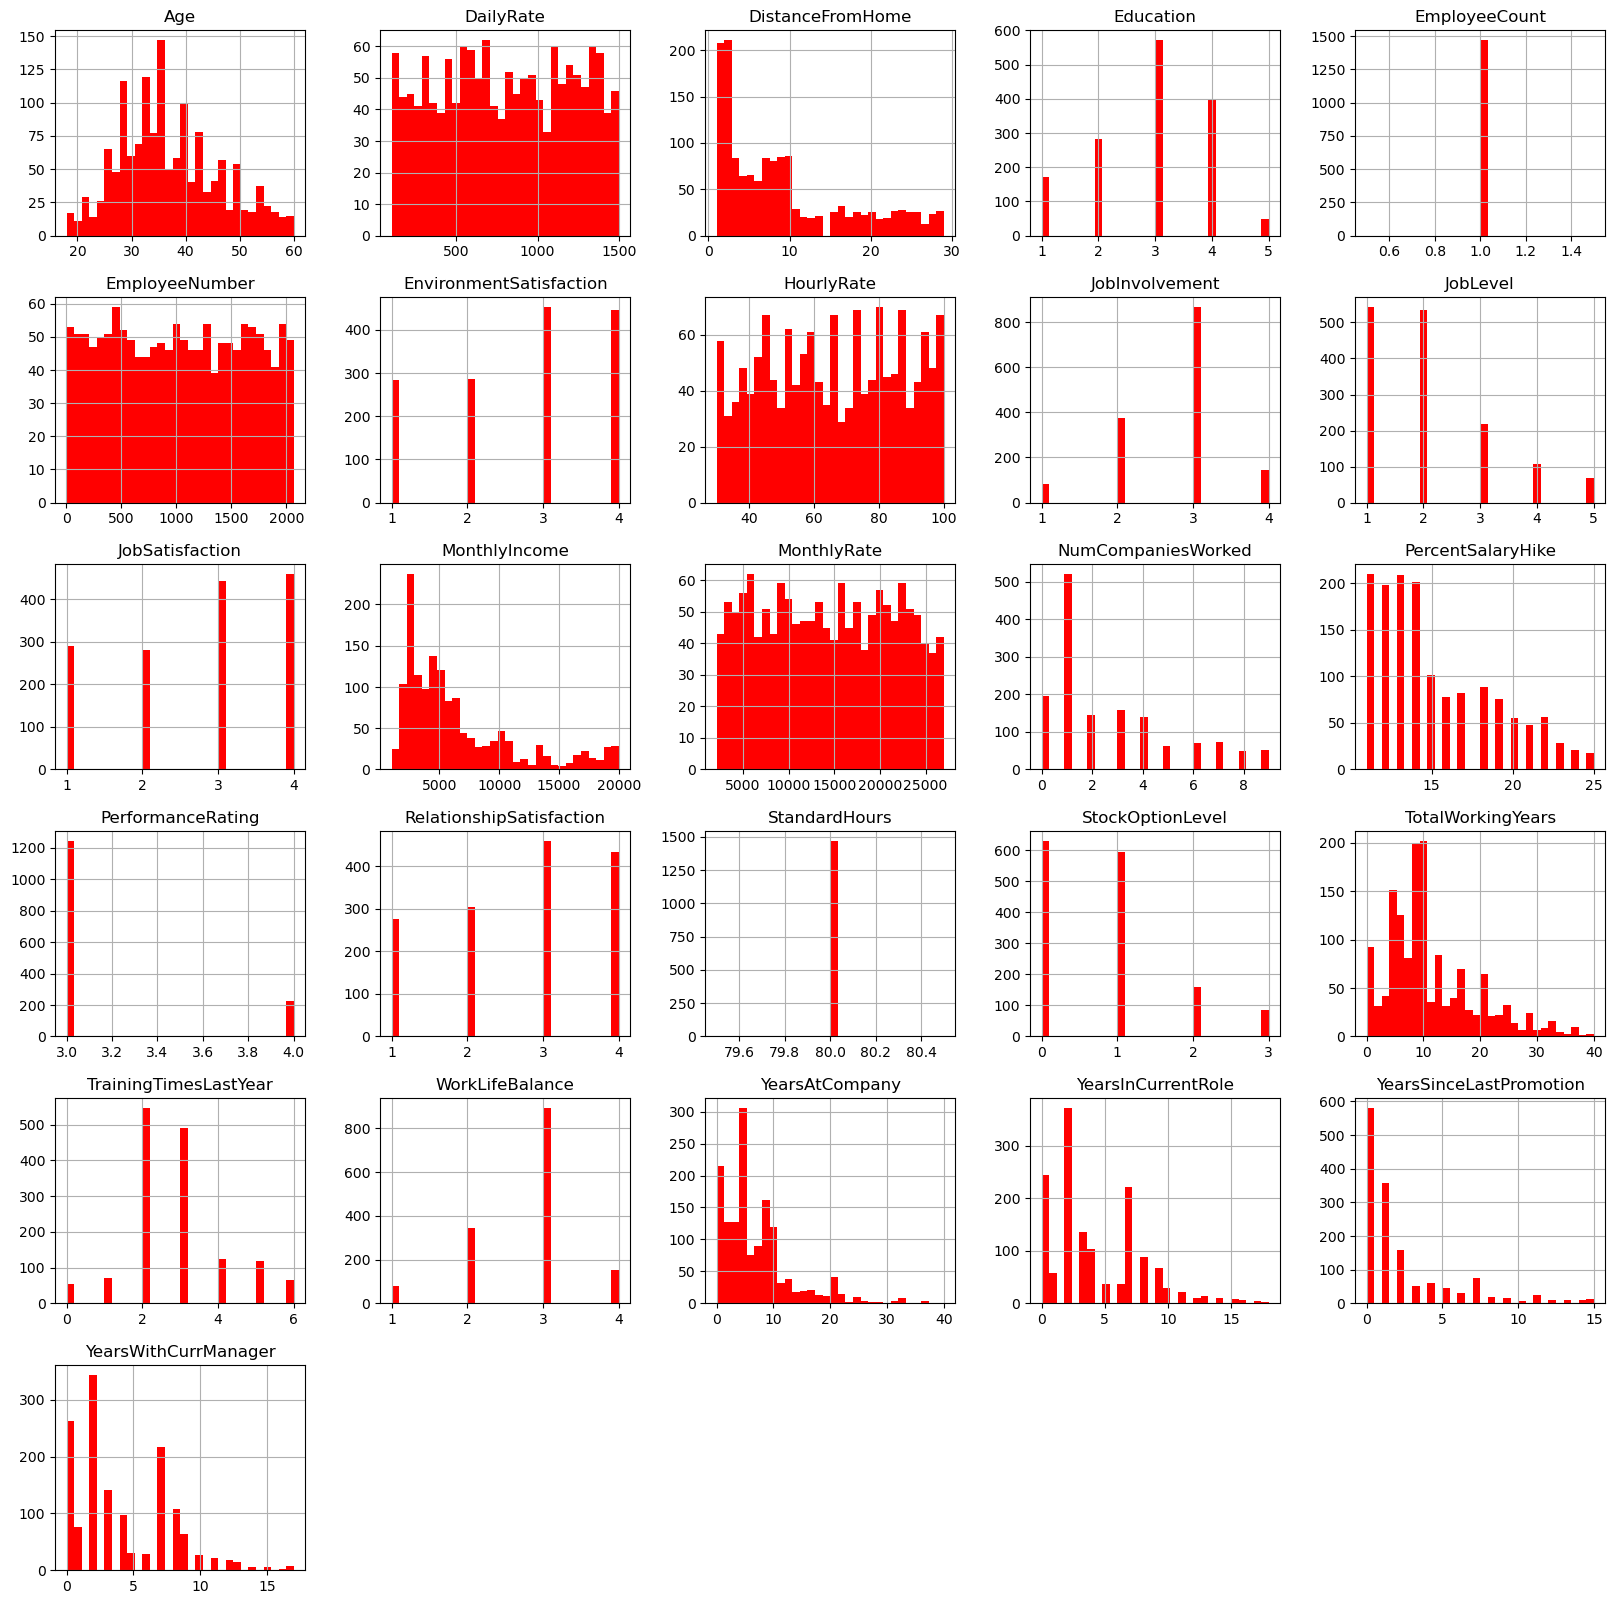

In [9]:
#checking features with histograms 
employee_df.hist(bins = 30, figsize = (20,20), color = 'r')

In [10]:
#according to histogramms we can drop constant features because it doesnt play any role in prediction
employee_df.drop(['Over18','EmployeeCount','StandardHours'], axis = 1, inplace=True)
employee_df.head(3)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,3,2,0,7,3,3,0,0,0,0


In [11]:
#encoding target feature Attrition and OverTime categorical feature from Yes/No to 0/1
employee_df['Attrition'] =  employee_df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)
employee_df['OverTime'] = employee_df['OverTime'].apply(lambda x: 1 if x == 'Yes' else 0)

In [12]:
#Lets classify variables
def classify_variables(data):
    discrete = [var for var in data.columns if data[var].dtypes != 'O' and var != 'Attrition' and data[var].nunique() < 10]
    continous = [var for var in data.columns if data[var].dtypes != 'O' and var != 'Attrition' and var not in discrete]
    categorical = [var for var in data.columns if data[var].dtypes == 'O' and var != 'Attrition' ]

    
    print('{} discrete variables'.format(len(discrete)))
    print(discrete)
    print()
    print('{} continuos variables'.format(len(continous)))
    print(continous)
    print()
    print('{} categorical variables'.format(len(categorical)))
    print(categorical)

In [13]:
classify_variables(employee_df)

11 discrete variables
['Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'OverTime', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TrainingTimesLastYear', 'WorkLifeBalance']

14 continuos variables
['Age', 'DailyRate', 'DistanceFromHome', 'EmployeeNumber', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

6 categorical variables
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']


In [14]:
employee_df[['Attrition','OverTime']].head()

,Attrition,OverTime
0,1,1
1,0,0
2,1,1
3,0,1
4,0,0


In [15]:
#lets divide dataset into left and stayed employee to explore 
left_df = employee_df[employee_df['Attrition'] == 1]
stayed_df = employee_df[employee_df['Attrition'] == 0]

print('Total = ',len(employee_df))
print('Number of employees who left the company = ',len(left_df))
print('Percentage of employees who left the company = ',len(left_df)/len(employee_df)*100.0,"%")

print('Number of employees who stayed in the company = ',len(stayed_df))
print('Percentage of employees who stayed in the company = ',len(stayed_df)/len(employee_df)*100.0,"%")


Total =  1470
Number of employees who left the company =  237
Percentage of employees who left the company =  16.122448979591837 %
Number of employees who stayed in the company =  1233
Percentage of employees who stayed in the company =  83.87755102040816 %


In [16]:
#first conclusion that full dataset is disbalanced

In [17]:
discrete_and_continous = [var for var in employee_df.columns if employee_df[var].dtypes != 'O' and var != 'Attrition']
categorical = [var for var in employee_df.columns if employee_df[var].dtypes == 'O' and var != 'Attrition' ]

/var/folders/3b/1s2t7l_10xv3015h5jnc0t7h0000gn/T/ipykernel_3091/2636576264.py:2: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12,7))


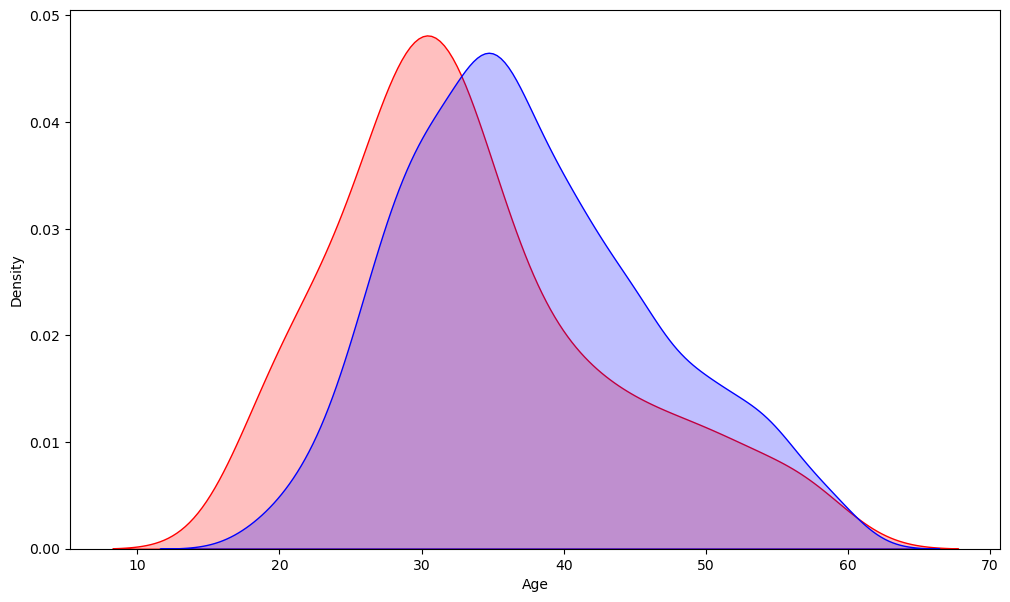

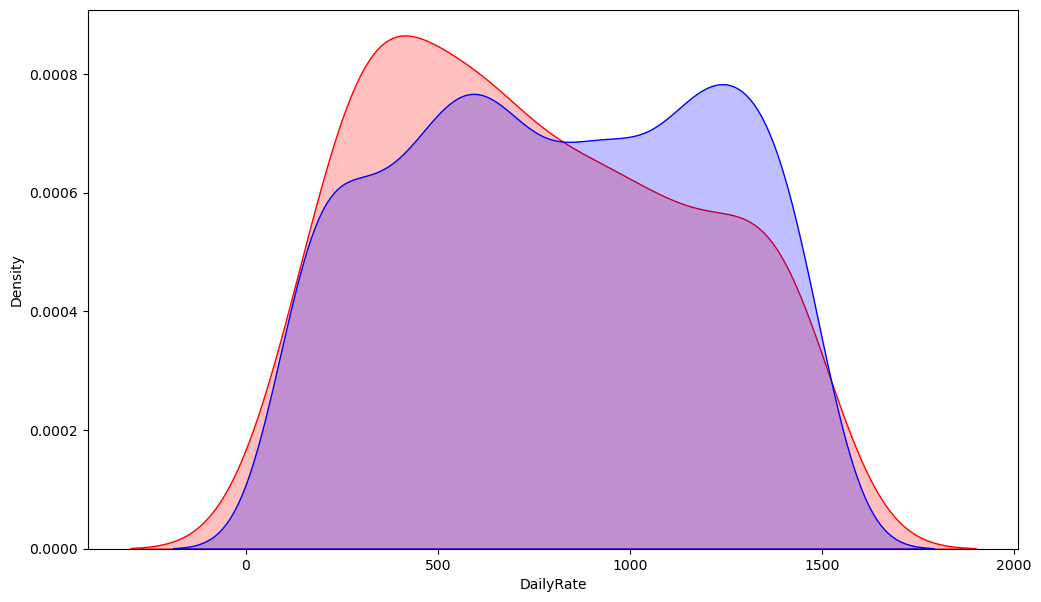

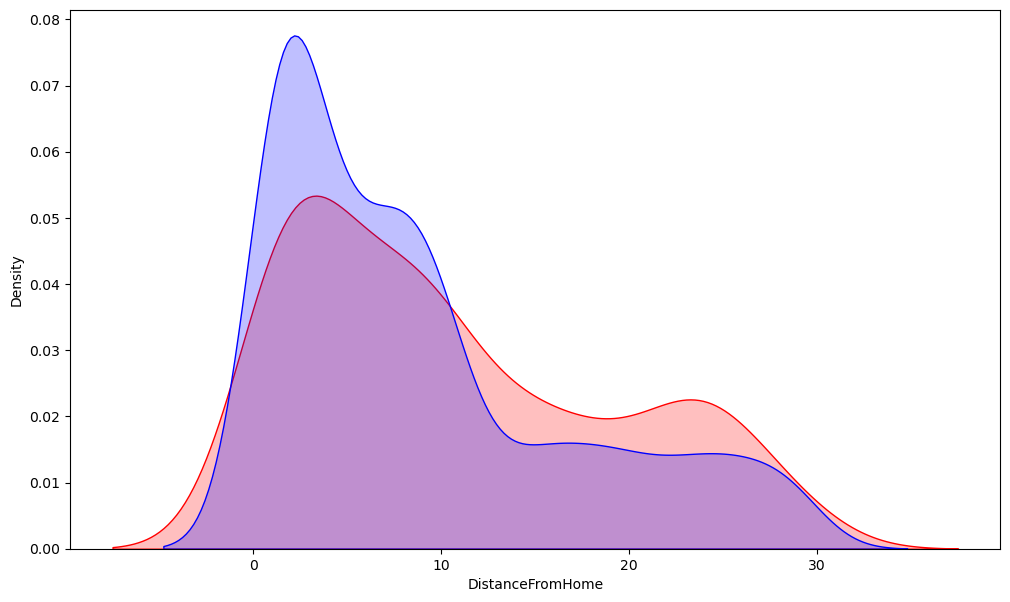

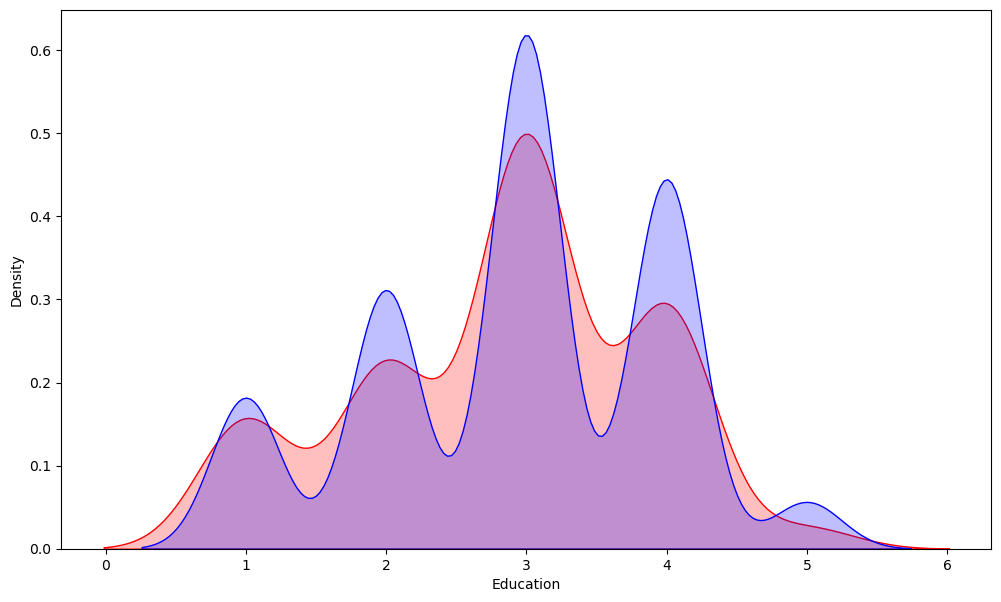

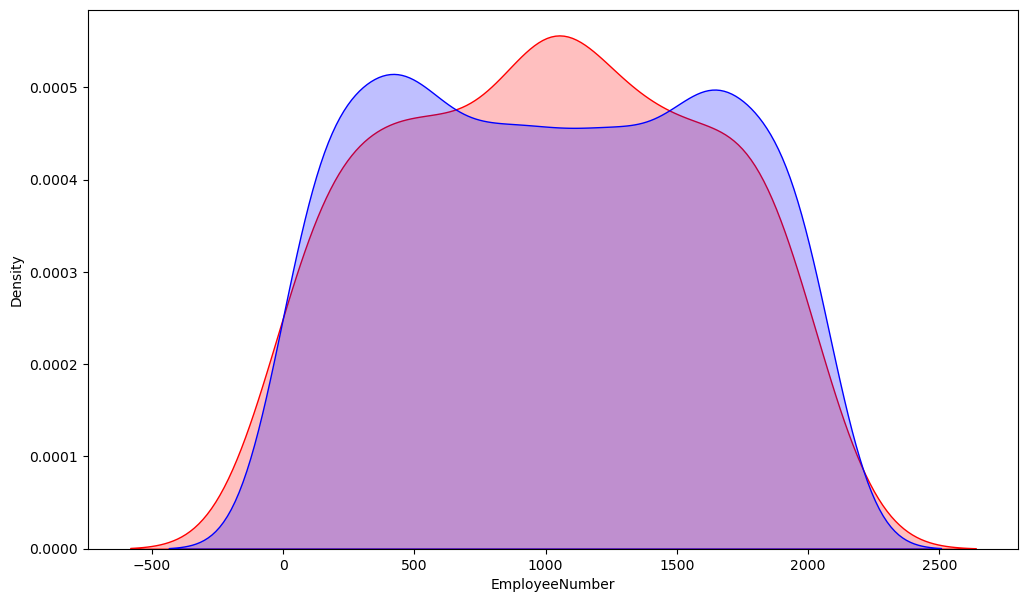

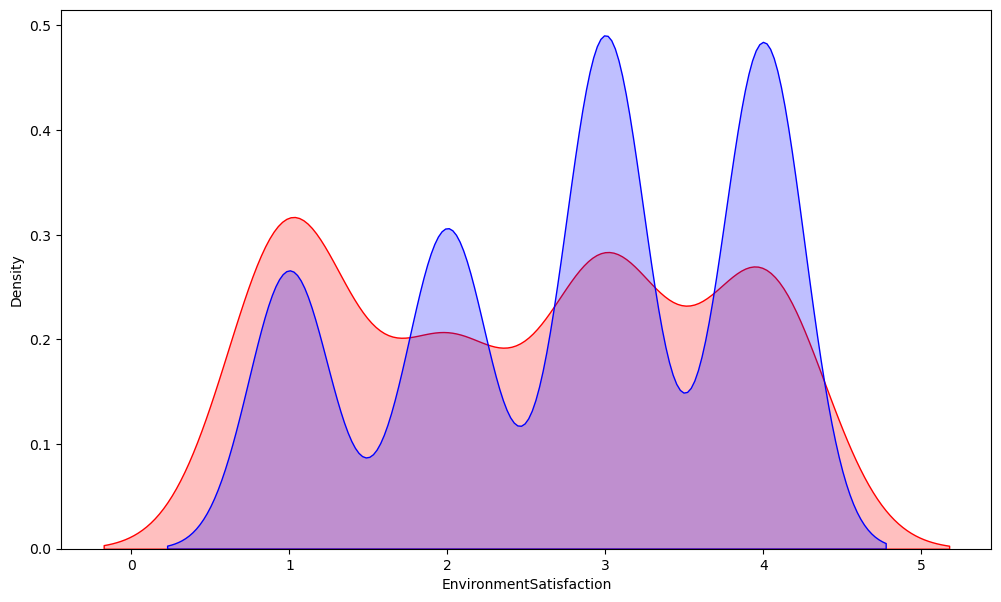

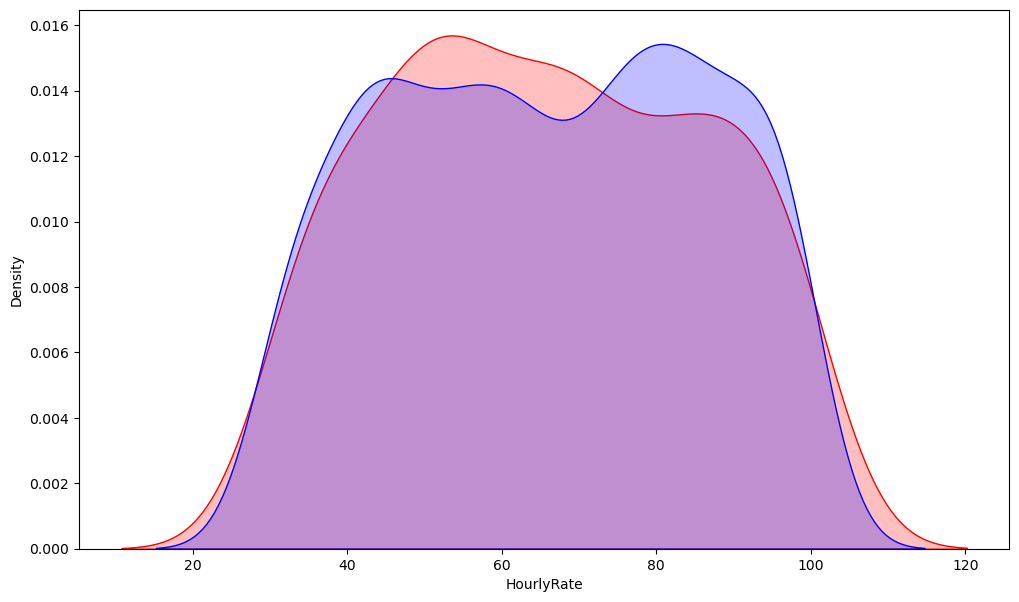

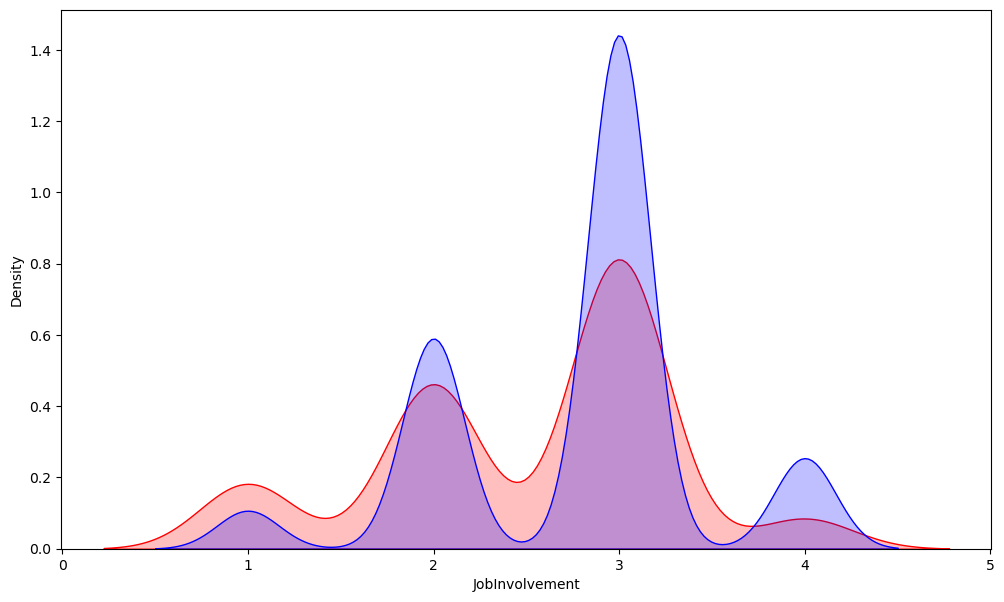

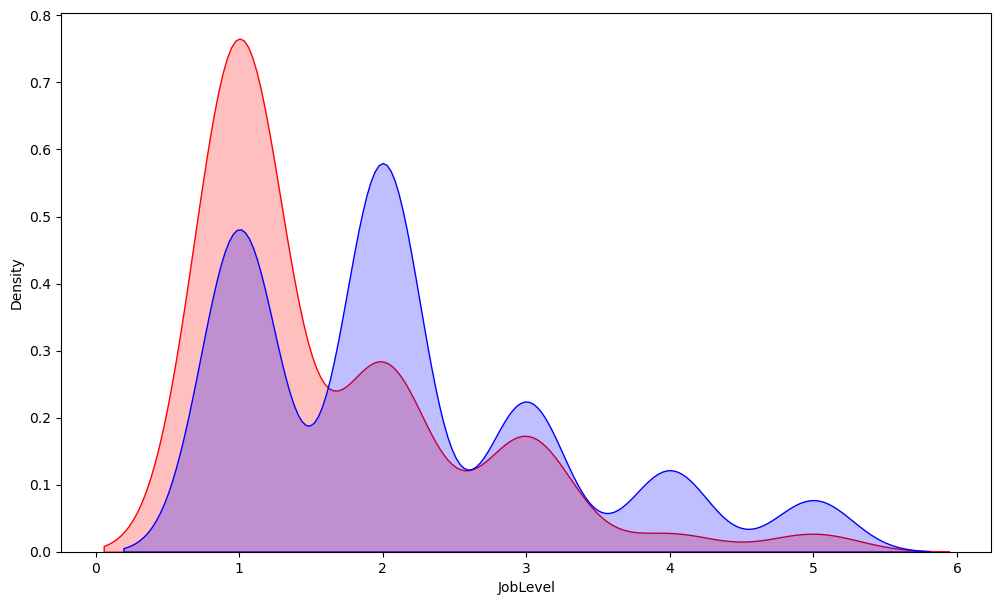

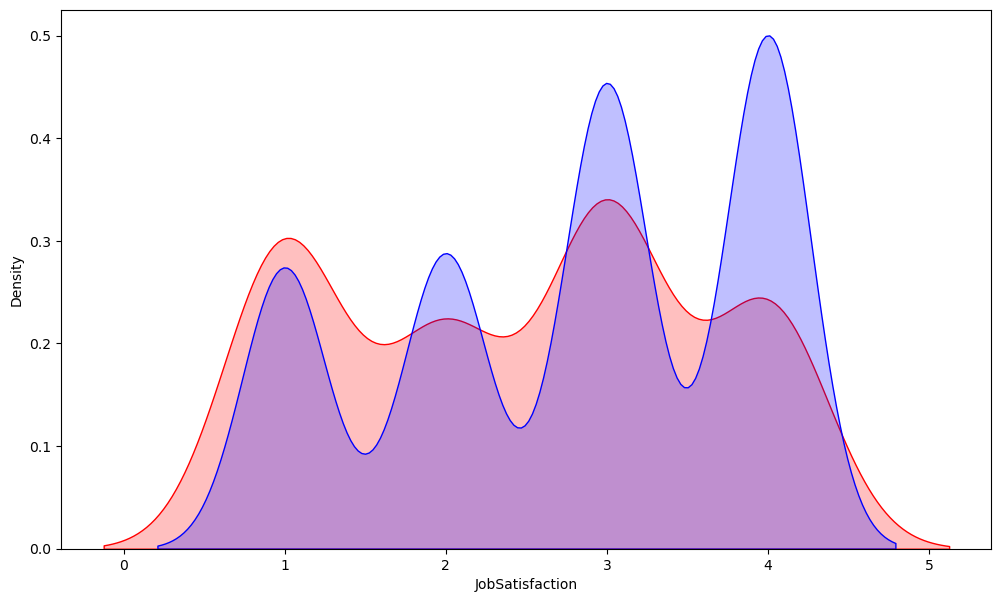

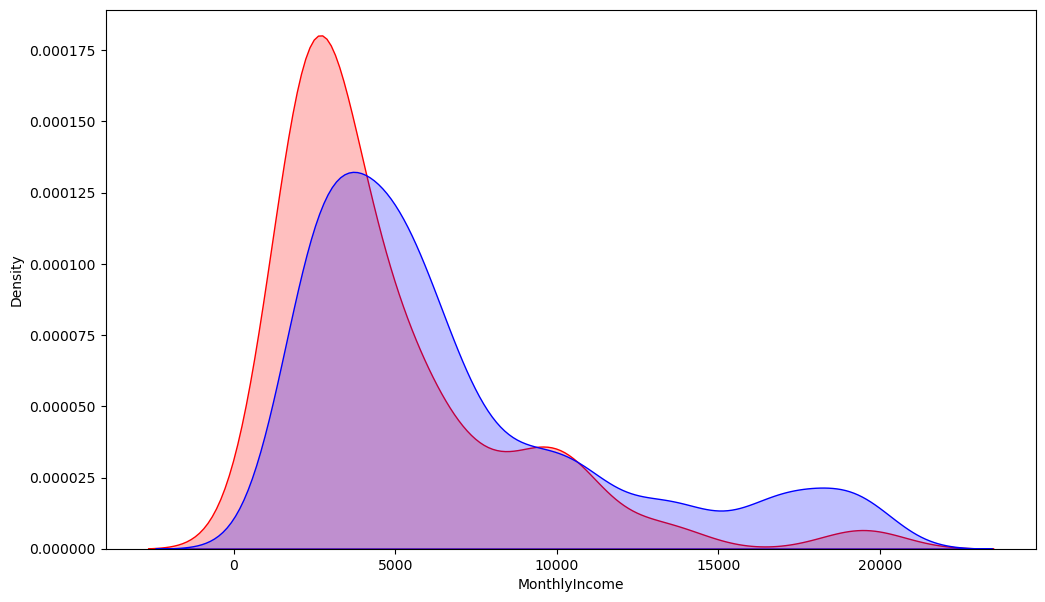

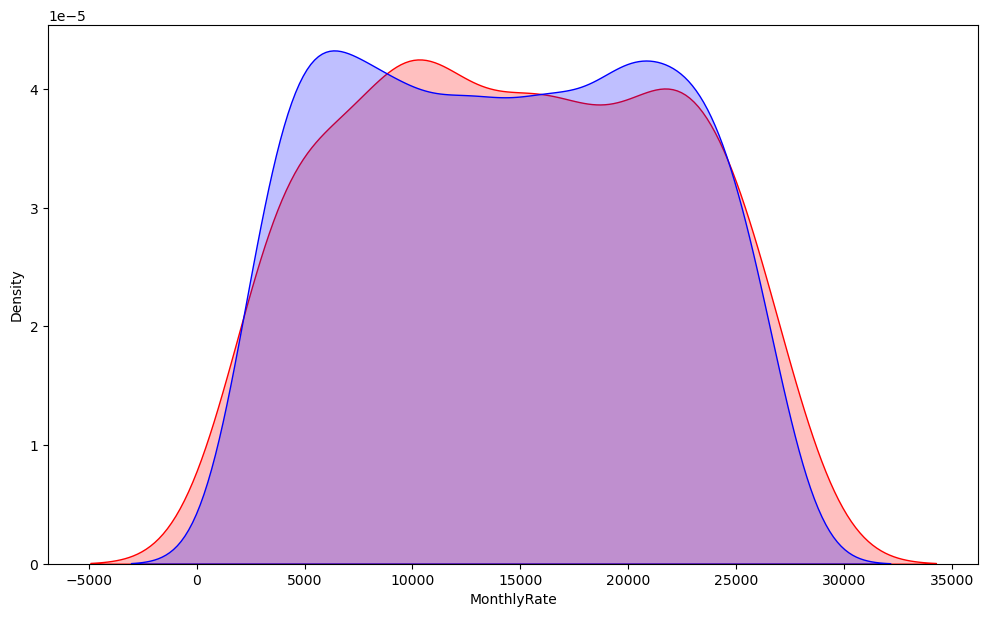

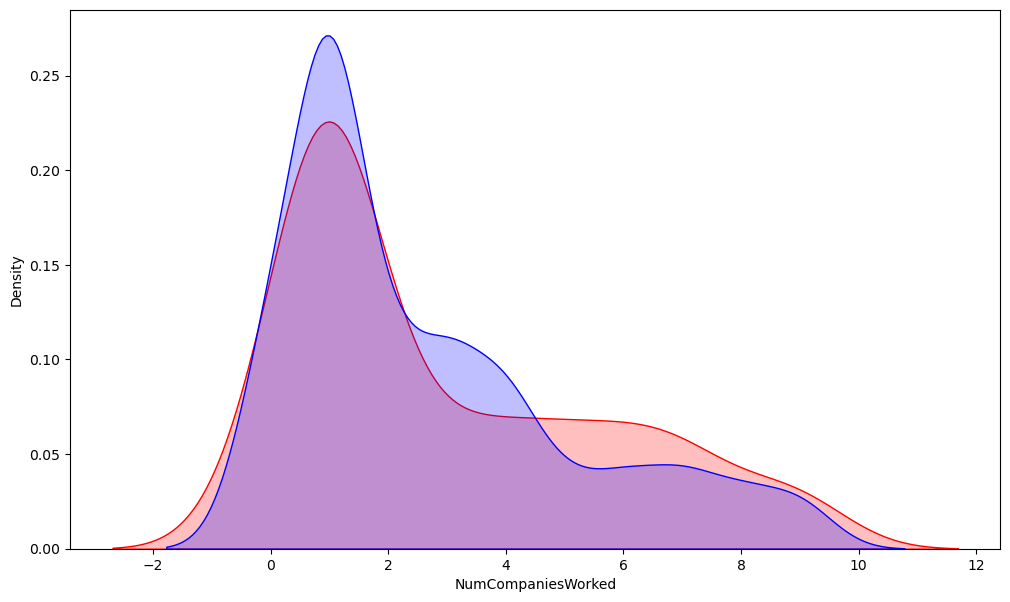

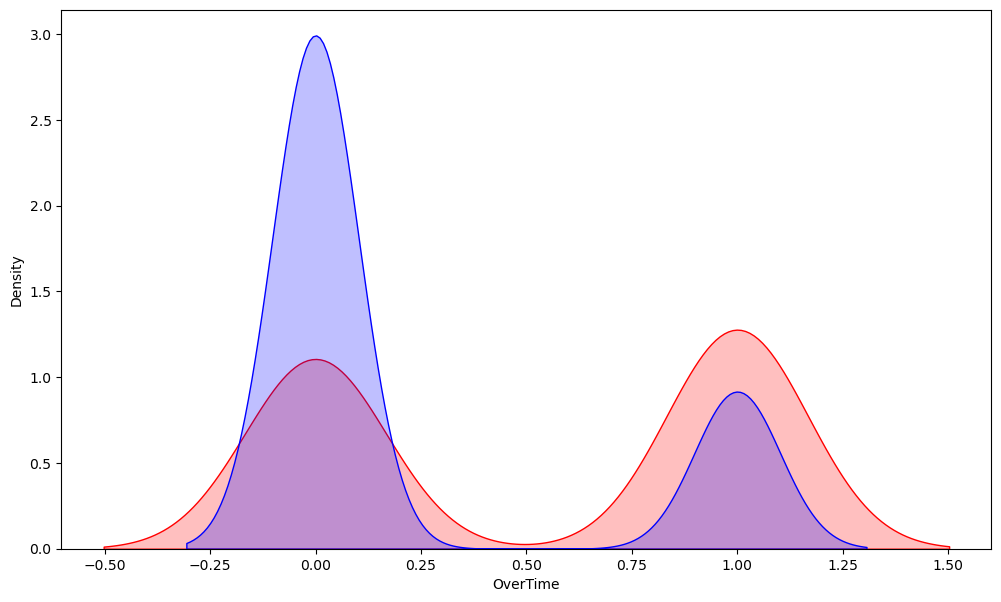

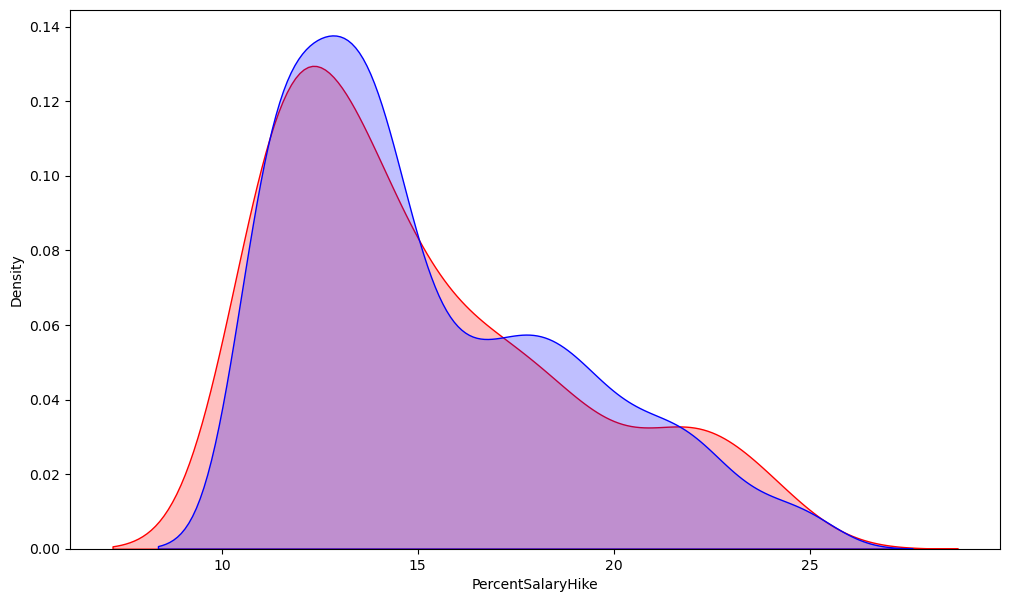

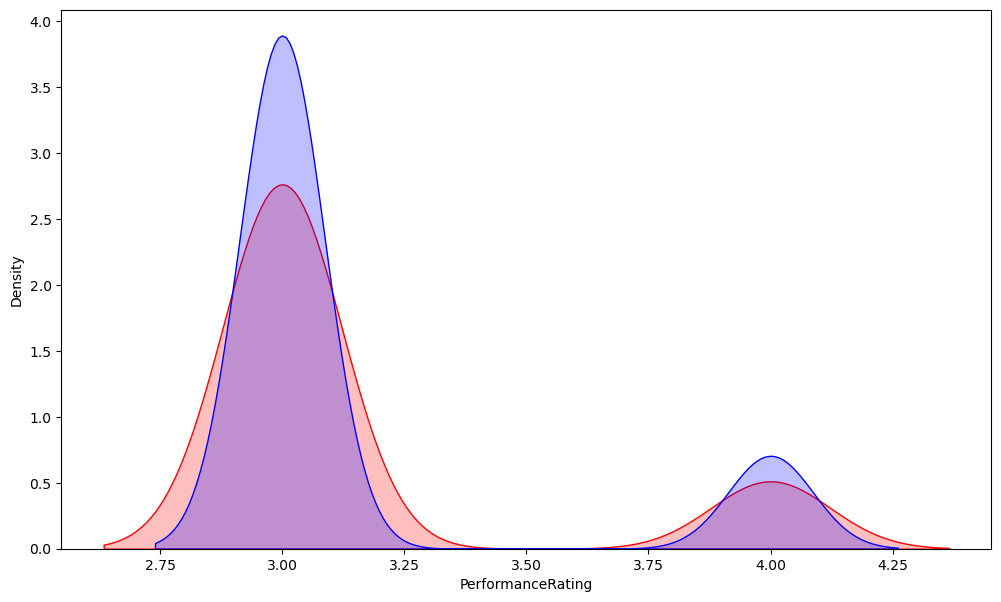

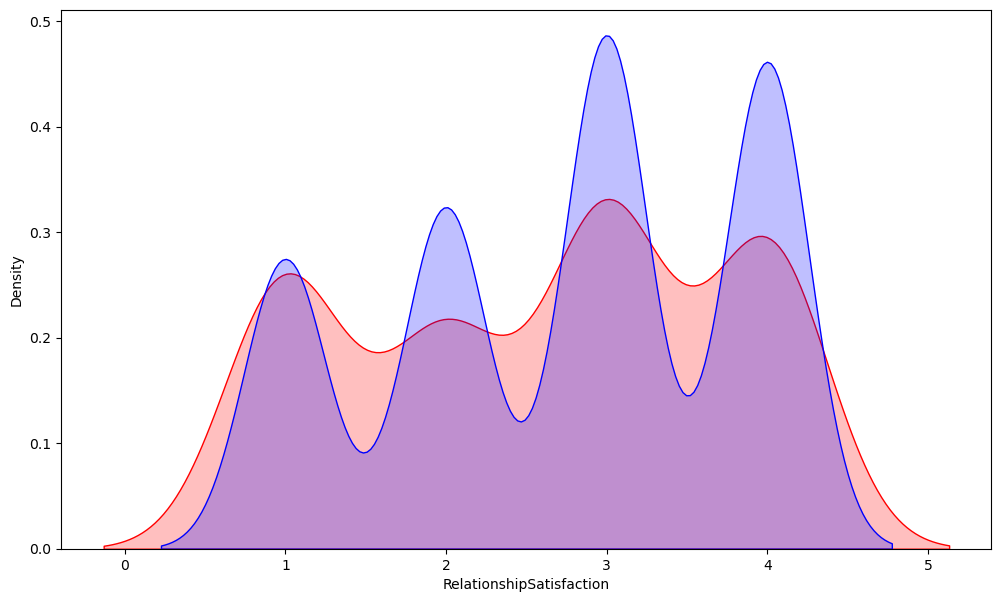

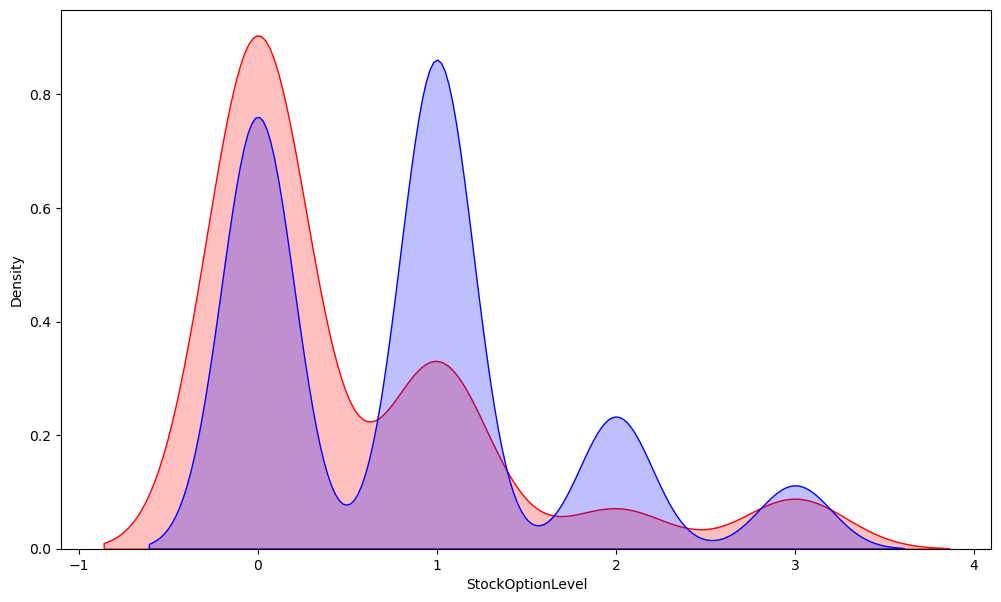

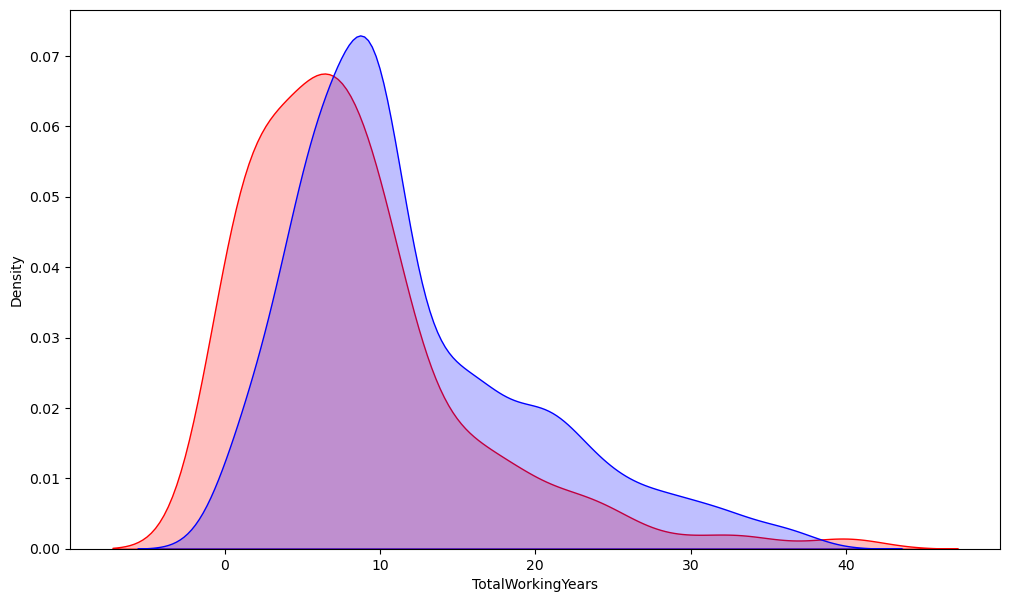

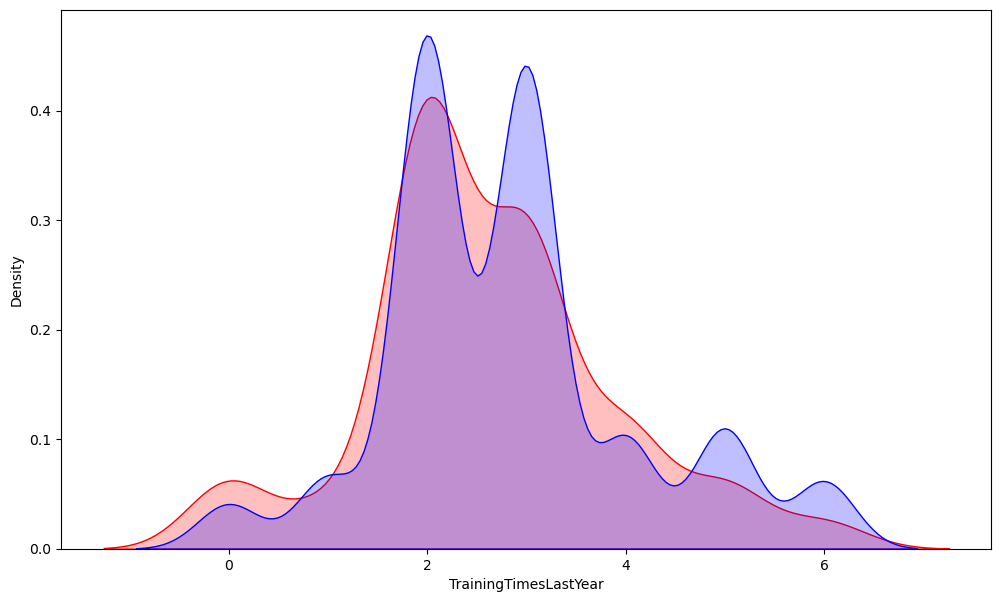

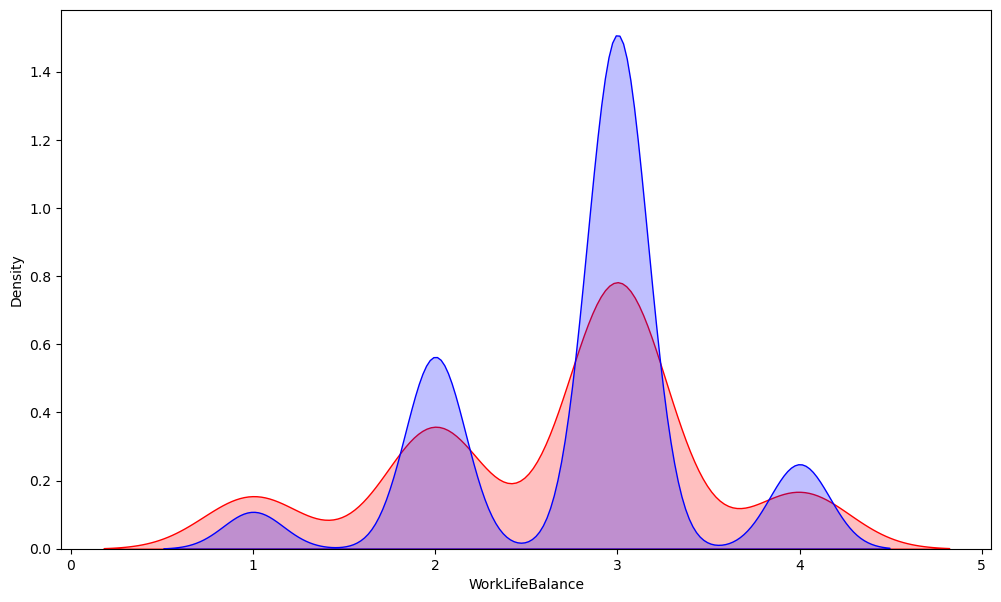

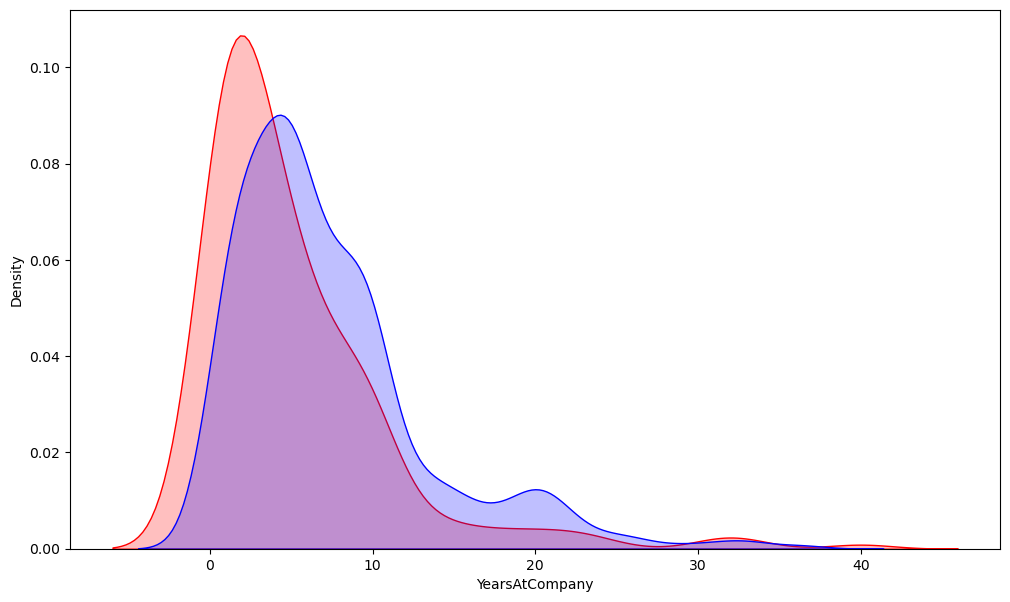

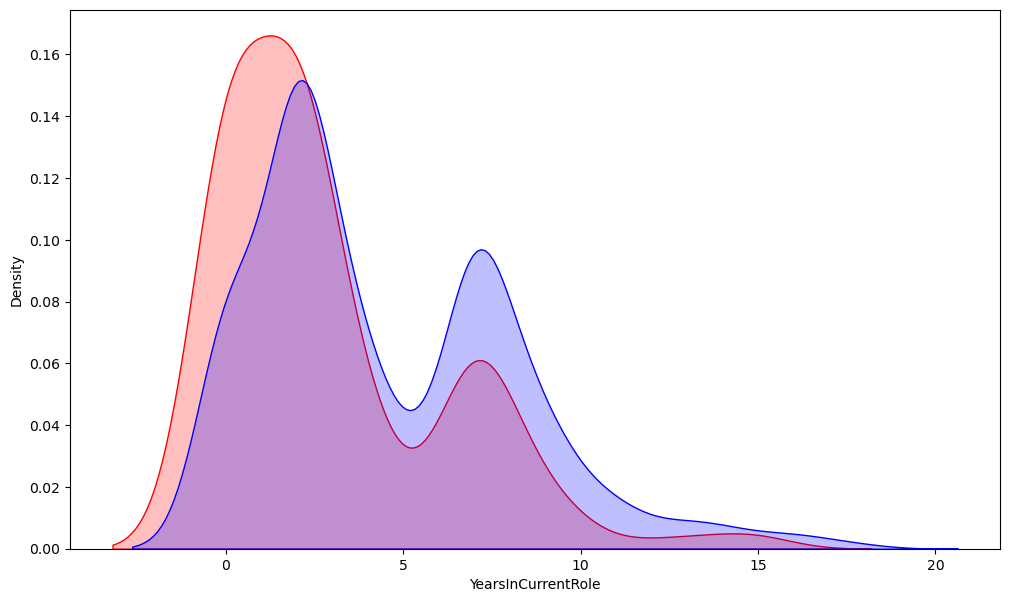

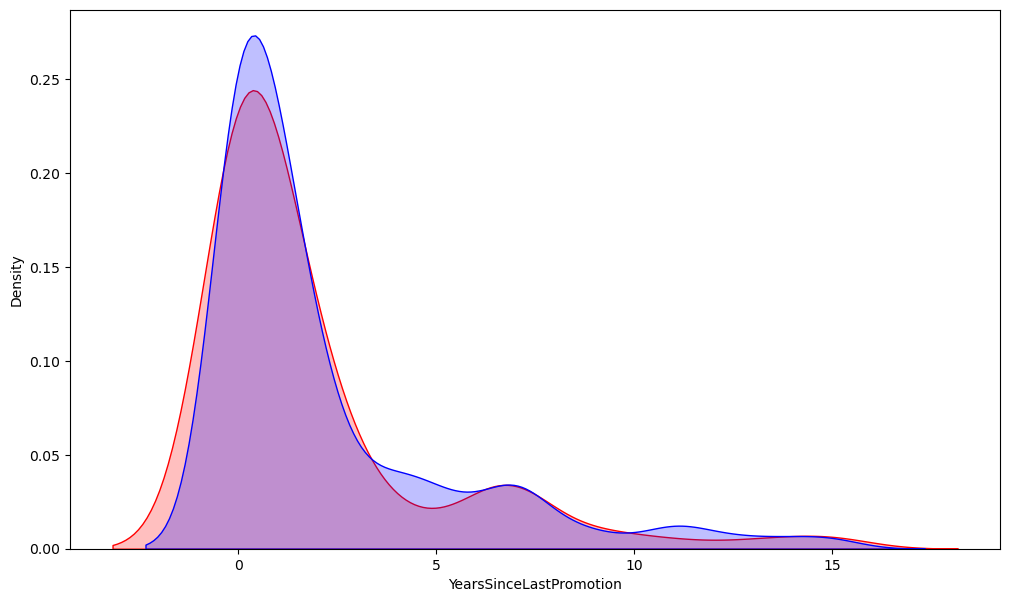

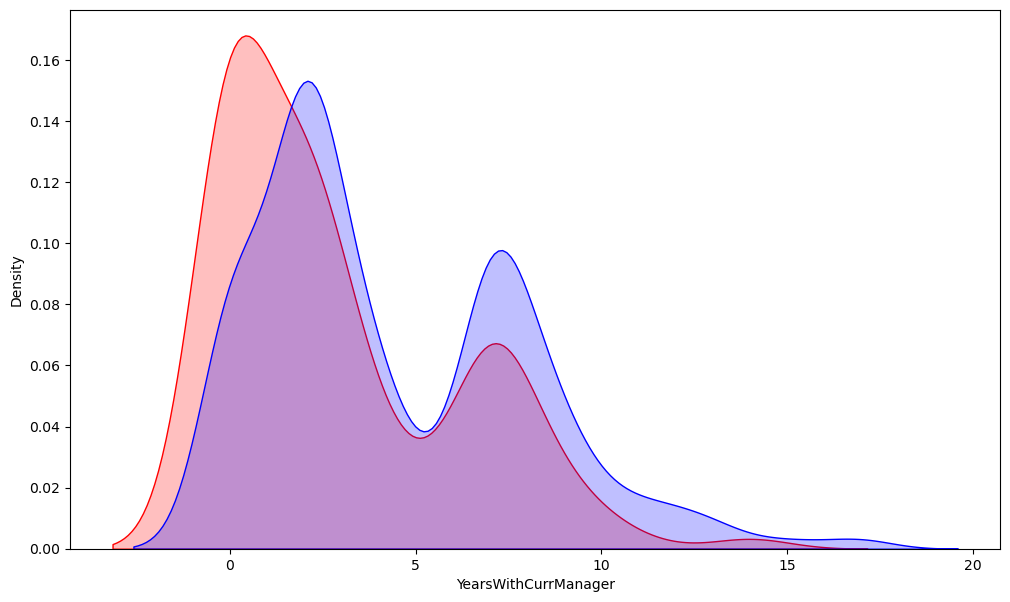

In [18]:
for var in discrete_and_continous:
    plt.figure(figsize=(12,7))
   
    sns.kdeplot(left_df[var], label = 'Employees who left', fill = True, color = 'r')
    sns.kdeplot(stayed_df[var], label = 'Employees who stayed', fill = True, color = 'b')
    plt.xlabel(var)
    

In [19]:
#AGE The most people left at 30s .Closer to 40s and older  we can see that mostly employee prefer to stay

#DAILY RATE and MONTHLY INCOME The most employee with lower rate left. After 1000($) daily rate left employee significantly reducing

# DISTANCE FROM HOME We clearly can see that in general if workplace closer to home the most employee stays, but at the same time they quit probably because get bored/tired from to the same area of living and working

# JOB LEVEL The most employee with high level position stays and quit less often. The most with low position quit often.

#NUM COMPANIES WORK Employee who worked in 1-2 places quit less than people who changed more than 5 work places

#OVER TIME Employee works overtime quit more often

#RELATIONSHIP SATISFACTION The more employee satisfied with relationships the less they left

# TOTAL WORKING YEARS Employee who works more than 10 years in total prefer to stay  
# YEARS AT COMPANY first 1-3 years employee quit often than people after 5 and more years at one company

#YEARS IN CURRENT ROLE people worked 5 and more years in the same role prefer to stay, less to quit



<Axes: >

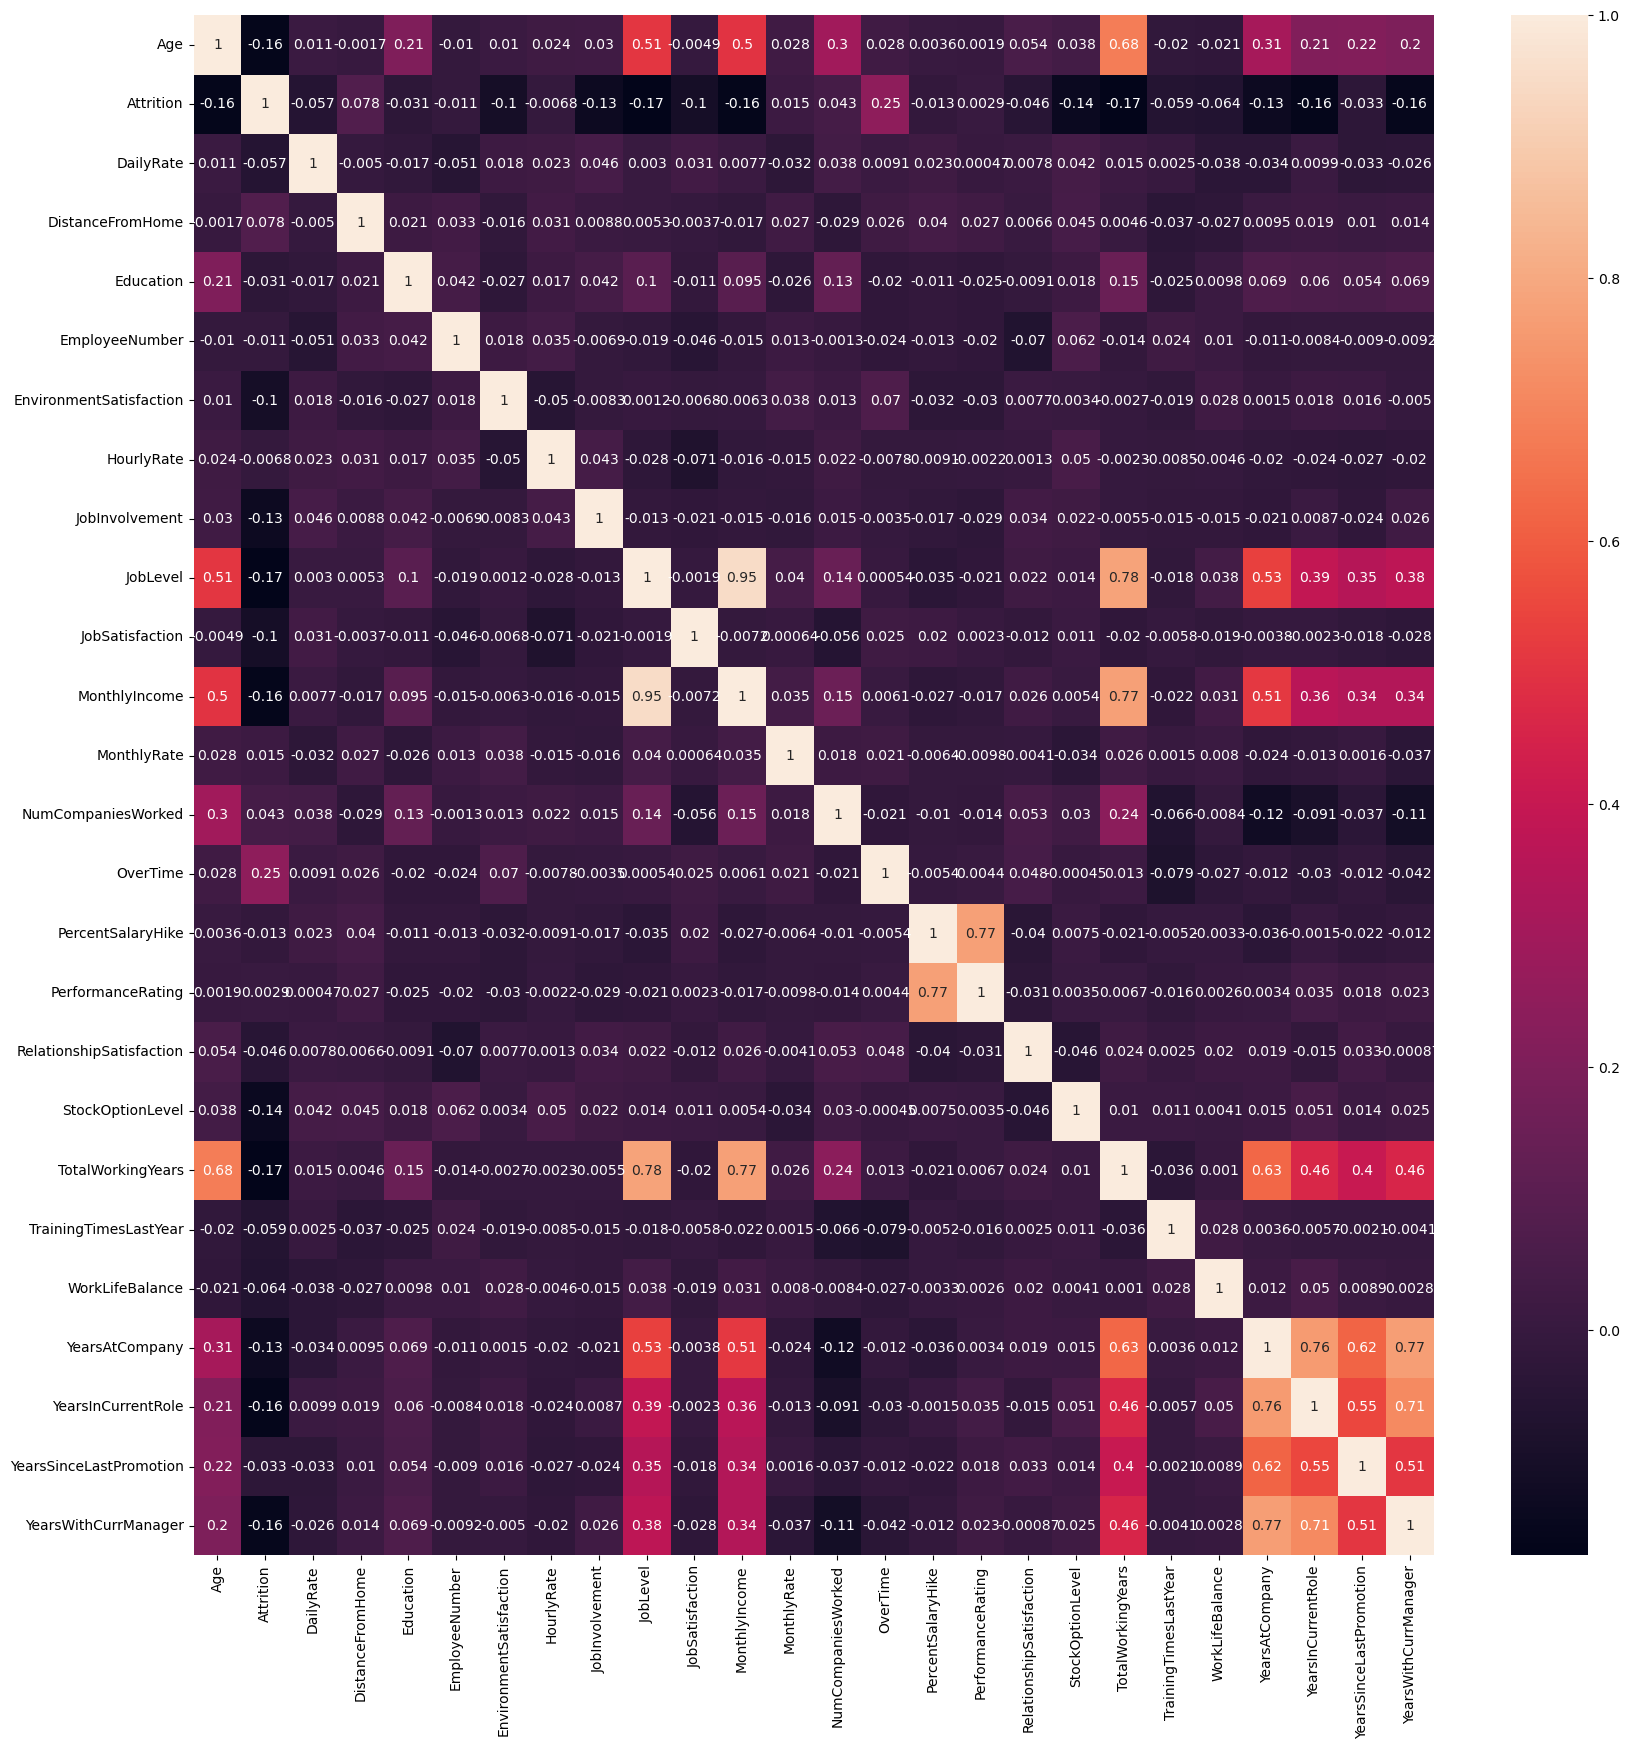

In [20]:
correlations = employee_df.corr(numeric_only= True)
f, ax = plt.subplots(figsize = (20,20))
sns.heatmap(correlations, annot = True) 

In [21]:
#high corellated features is JobLevel and Monthly income, but it is going to be dropped later

<Axes: xlabel='Age', ylabel='count'>

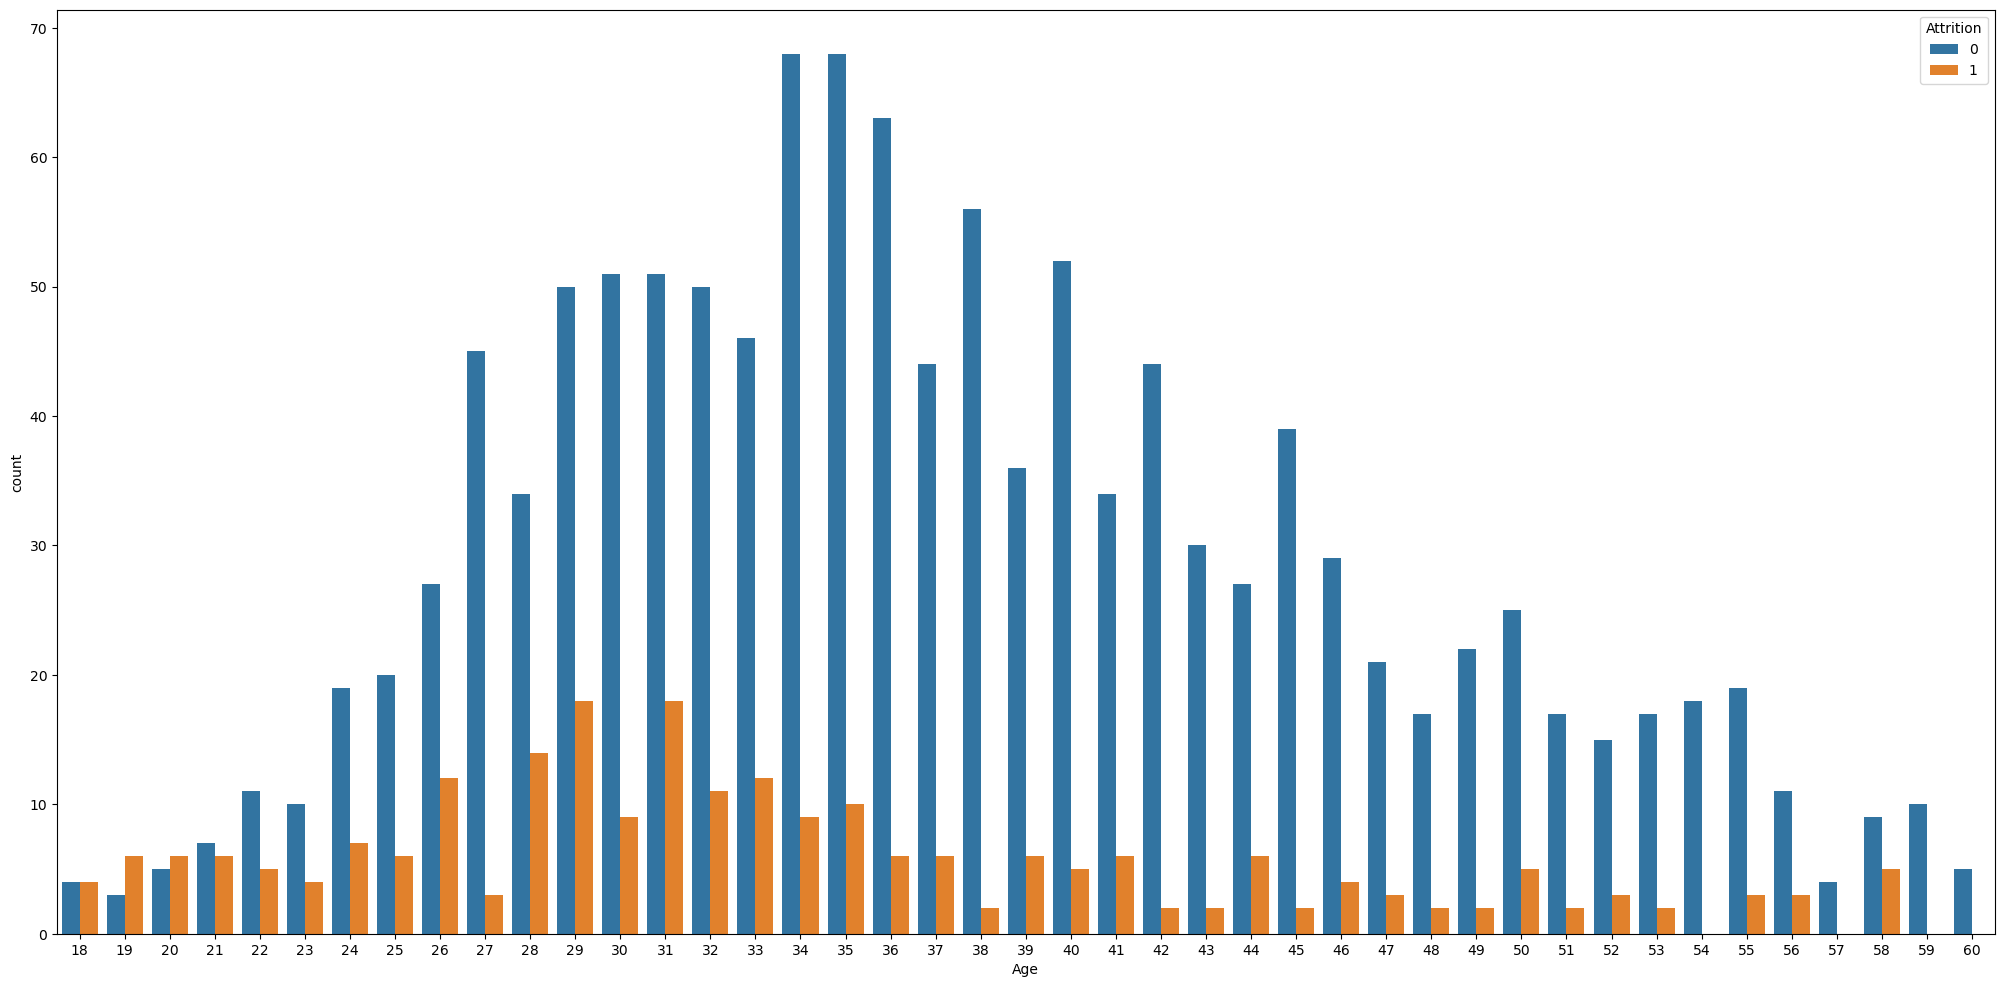

In [22]:
plt.figure(figsize= [25,12])
sns.countplot(x = 'Age',hue = 'Attrition', data = employee_df)
#according to figure I think
#that the most employee quil from 28-31y because after degree they got enough experience to get promotion
#and try something new
#then we can see that people after their 50 less often left probably because of age anfd they plan to
#retirement
#and probably at 58y increased amount of left employee means retirement  

612
613
614
615
616
617


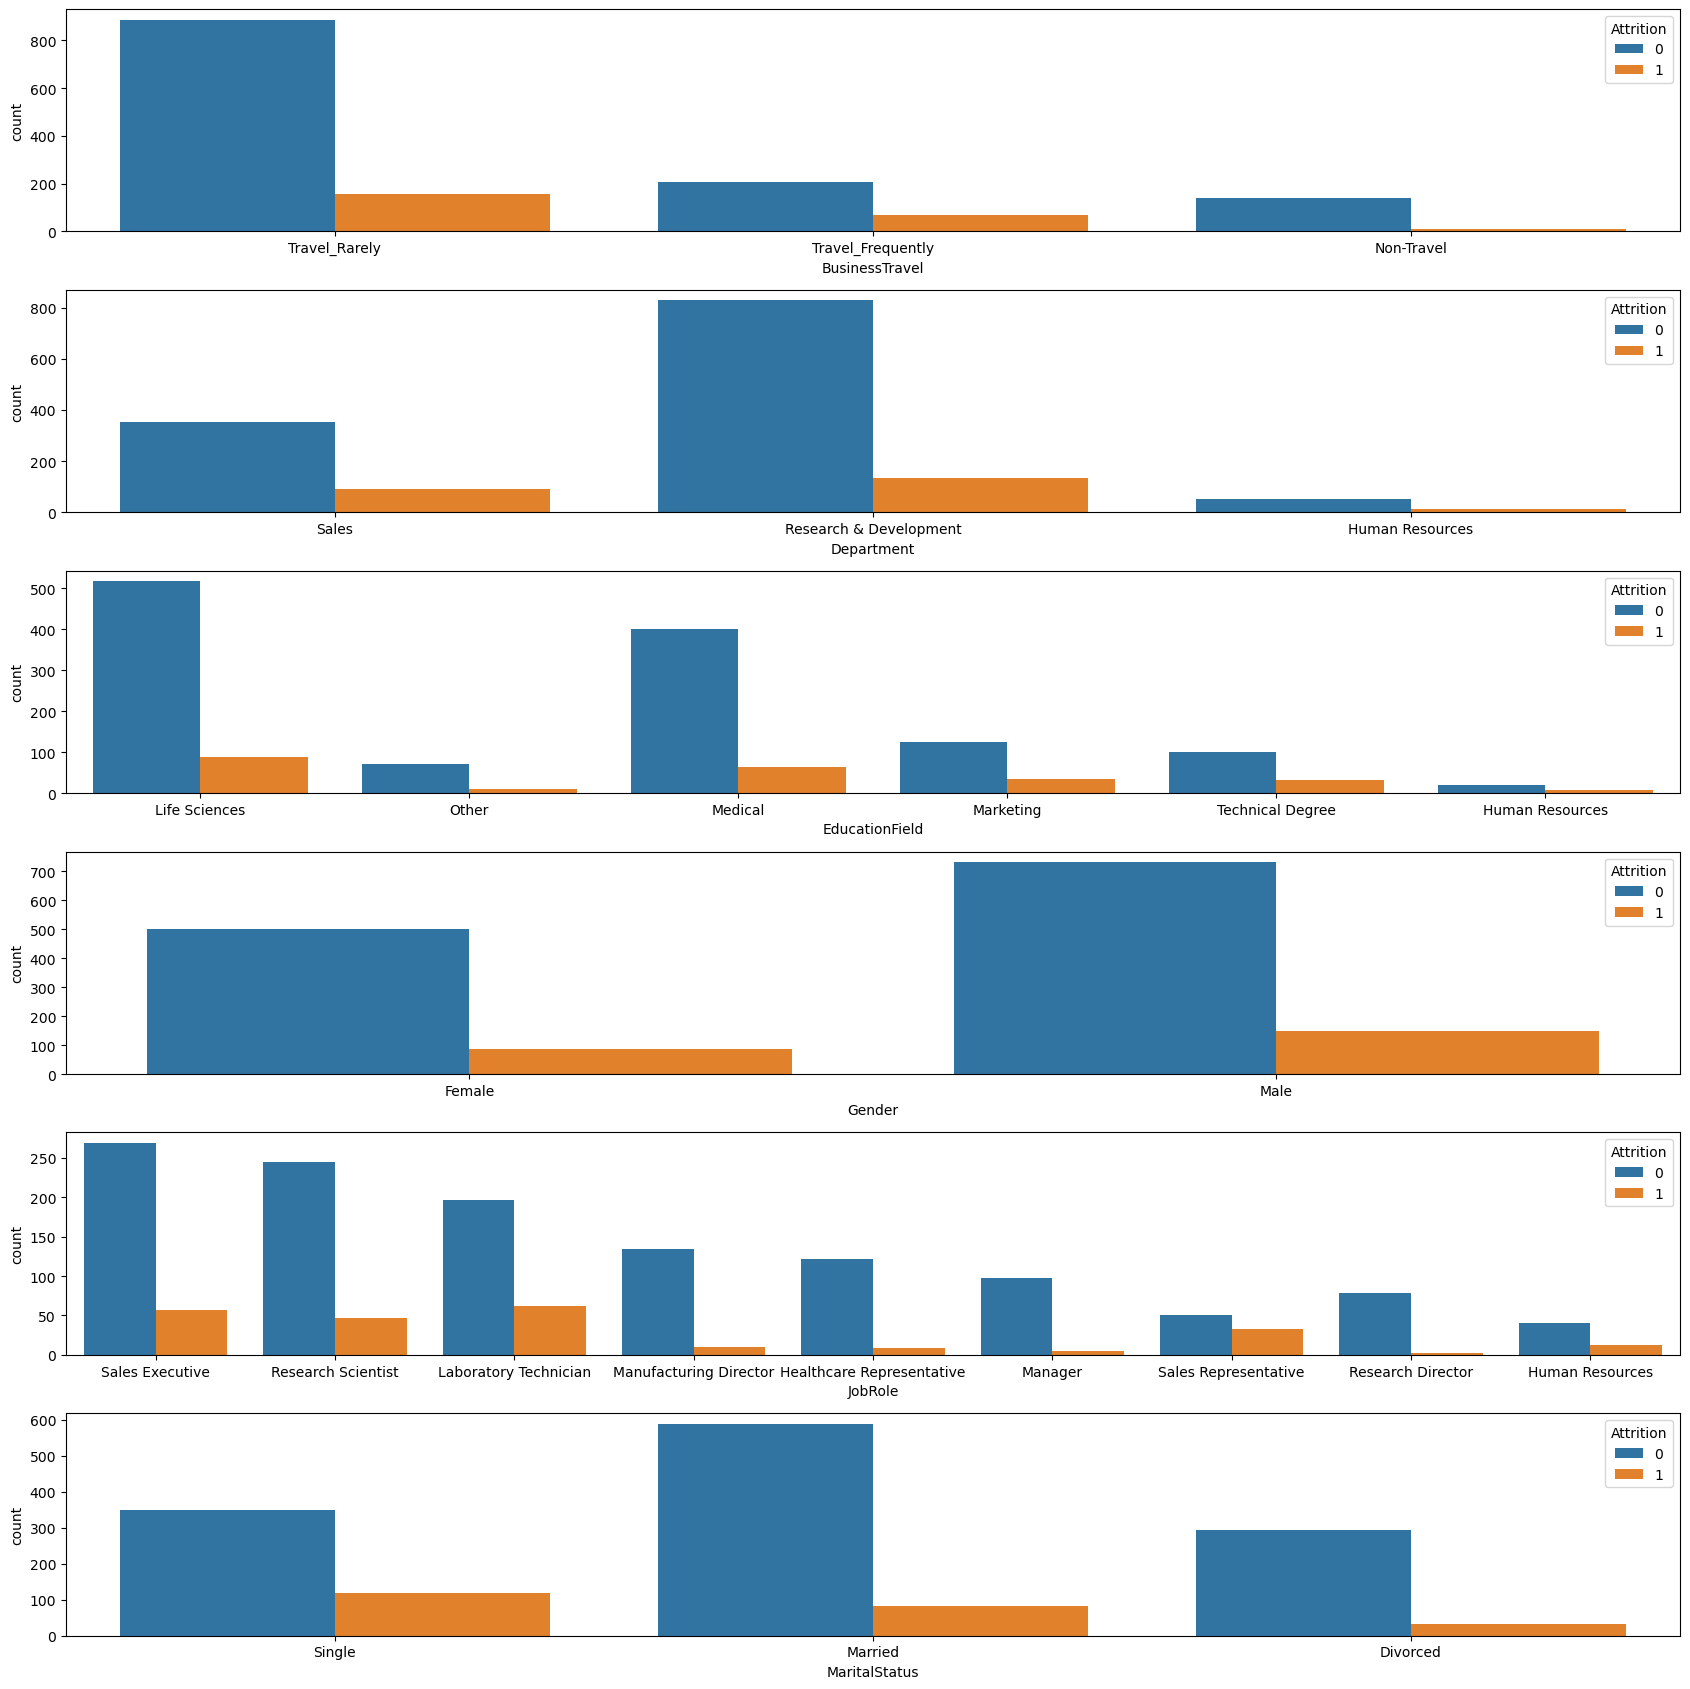

In [23]:
c = 611
plt.figure(figsize=(17,17))
for var in categorical:
    
    plt.subplot(c)
    sns.countplot(x = var, hue = 'Attrition', data = employee_df)
    c = c+1
    print(c)
    

plt.tight_layout()

In [24]:
# 1st looks like employee prefer balance between Non-traveling job and Frequently traveling job
## 2nd employees from Research and developmemt department quit job more often tham Sales,but also more employee 
# stayed than in Sales department. HR Department looks more stable comparing to others

#4 Seemed like Male epmloyee quit more often than female
##5 Employee with Labaratory Technician quit more than others, guess that they got hunted to other more 
## payed job. What comes to Sales Executive it might depend on job performance 
#6 Maried employees stayed the most, also singe employee quit more than Married and Divorced
#thin that is all about stable income in Mariage to cover montly expenses 

<Axes: xlabel='MonthlyIncome', ylabel='Gender'>

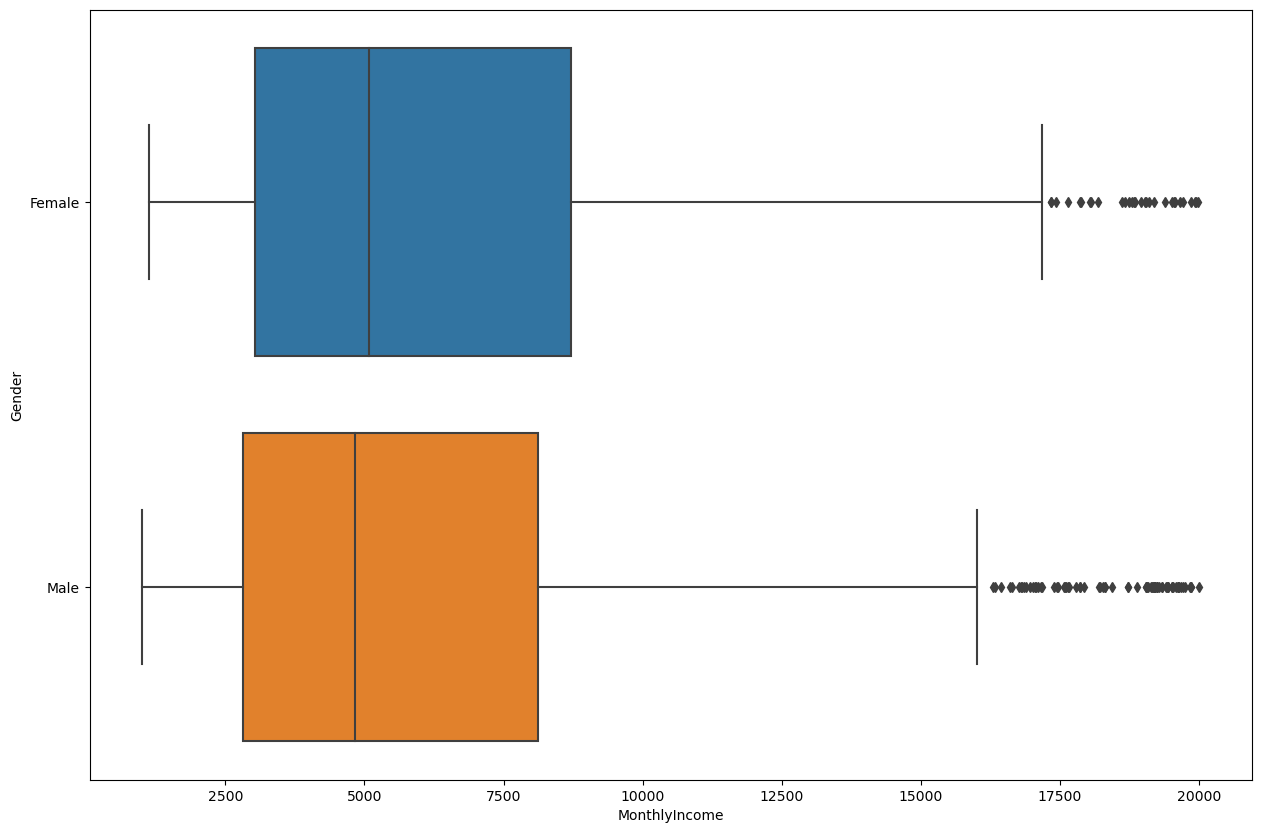

In [25]:
plt.figure(figsize=(15,10))
sns.boxplot(x = 'MonthlyIncome', y = 'Gender', data = employee_df)

In [26]:
#seemed like Female employee earn more that Male employee in this company

<Axes: xlabel='MonthlyIncome', ylabel='JobRole'>

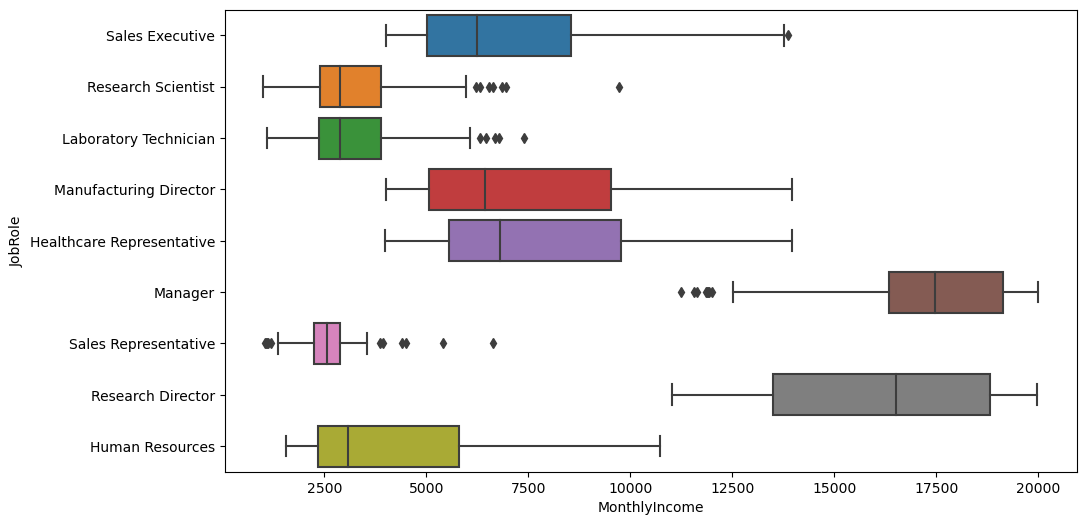

In [27]:
#checking high correlated features according to heatmap
plt.figure(figsize=(11,6))
sns.boxplot(x = 'MonthlyIncome', y = 'JobRole', data = employee_df)

In [28]:
#The most paid roles are SalesRepresentative and RecearchDirector, the less paid is Sales Representative

# FEATURE ENCODING

In [29]:
employee_df[categorical].nunique()

BusinessTravel    3
Department        3
EducationField    6
Gender            2
JobRole           9
MaritalStatus     3
dtype: int64

In [30]:
# Since Gender feature has only two unique values, I think its ok to use OHE because its not going to expand
#feature space
one_hot_encoder =  OneHotEncoder(
    top_categories= None,
    variables=['Gender'],
    drop_last= True
)
# drop_last = True to not expand dataset
employee_df = one_hot_encoder.fit_transform(employee_df)

In [31]:
employee_df.head(3)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Gender_Female
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,1,0,8,0,1,6,4,0,5,1
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,4,1,10,3,3,10,7,1,7,0
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,2,0,7,3,3,0,0,0,0,0


In [32]:
#for other categorical features better use Ordinal encoder because it is not going to expand the feature space
#and work good with tree base algorithms 

In [33]:
ordinal_encoder = OrdinalEncoder(
    encoding_method= 'ordered',
    variables =  ['BusinessTravel','Department','JobRole','EducationField','MaritalStatus']
)

In [34]:
ordinal_encoder.variables

['BusinessTravel', 'Department', 'JobRole', 'EducationField', 'MaritalStatus']

In [35]:
employee_df= ordinal_encoder.fit_transform(employee_df, employee_df['Attrition'])

employee_df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Gender_Female
0,41,1,1,1102,2,1,2,2,1,2,...,1,0,8,0,1,6,4,0,5,1
1,49,0,2,279,0,8,1,2,2,3,...,4,1,10,3,3,10,7,1,7,0
2,37,1,1,1373,0,2,2,0,4,4,...,2,0,7,3,3,0,0,0,0,0
3,33,0,2,1392,0,3,4,2,5,4,...,3,0,8,3,3,8,7,3,0,1
4,27,0,1,591,0,2,1,1,7,1,...,4,1,6,3,3,2,2,2,2,0
5,32,0,2,1005,0,2,2,2,8,4,...,3,0,8,2,2,7,7,3,6,0
6,59,0,1,1324,0,3,3,1,10,3,...,1,3,12,3,2,1,0,0,0,1
7,30,0,1,1358,0,24,1,2,11,4,...,2,1,1,2,3,1,0,0,0,0
8,38,0,2,216,0,23,3,2,12,4,...,2,0,10,2,3,9,7,1,8,0
9,36,0,1,1299,0,27,3,1,13,3,...,2,2,17,3,2,7,7,7,7,0


In [36]:
#as we can see it didnt expand the feature space

In [37]:
#lets classify variables after encoding
classify_variables(employee_df)

17 discrete variables
['BusinessTravel', 'Department', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'OverTime', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TrainingTimesLastYear', 'WorkLifeBalance', 'Gender_Female']

14 continuos variables
['Age', 'DailyRate', 'DistanceFromHome', 'EmployeeNumber', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

0 categorical variables
[]


In [38]:
employee_df.info()
#all of features became to int64 type

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   int64
 2   BusinessTravel            1470 non-null   int64
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   int64
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   int64
 8   EmployeeNumber            1470 non-null   int64
 9   EnvironmentSatisfaction   1470 non-null   int64
 10  HourlyRate                1470 non-null   int64
 11  JobInvolvement            1470 non-null   int64
 12  JobLevel                  1470 non-null   int64
 13  JobRole                   1470 non-null   int64
 14  JobSatisfaction           1470 non-null 

In [39]:
#taking all the features except target to create X data set for spliting
X_cols = list(employee_df.select_dtypes(include= ['int64']))
X_cols.remove('Attrition')
X_cols

['Age',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager',
 'Gender_Female']

In [40]:
#creating X dataset without target
X = employee_df[X_cols]
X.head(2)

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Gender_Female
0,41,1,1102,2,1,2,2,1,2,94,...,1,0,8,0,1,6,4,0,5,1
1,49,2,279,0,8,1,2,2,3,61,...,4,1,10,3,3,10,7,1,7,0


In [41]:
#taking target to y
y = employee_df['Attrition']
X.shape, y.shape

((1470, 31), (1470,))

In [42]:
X.shape

(1470, 31)

# Normalization of numeric features 

In [43]:
scaler = MinMaxScaler()
#X.columns = X.columns.astype(str)
X = scaler.fit_transform(X)
X = pd.DataFrame(X)
X.head(10)

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
0,0.547619,0.5,0.715820,1.0,0.000000,0.25,0.4,0.000000,0.333333,0.914286,...,0.000000,0.000000,0.200,0.000000,0.000000,0.150,0.222222,0.000000,0.294118,1.0
1,0.738095,1.0,0.126700,0.0,0.250000,0.00,0.4,0.000484,0.666667,0.442857,...,1.000000,0.333333,0.250,0.500000,0.666667,0.250,0.388889,0.066667,0.411765,0.0
2,0.452381,0.5,0.909807,0.0,0.035714,0.25,0.0,0.001451,1.000000,0.885714,...,0.333333,0.000000,0.175,0.500000,0.666667,0.000,0.000000,0.000000,0.000000,0.0
3,0.357143,1.0,0.923407,0.0,0.071429,0.75,0.4,0.001935,1.000000,0.371429,...,0.666667,0.000000,0.200,0.500000,0.666667,0.200,0.388889,0.200000,0.000000,1.0
4,0.214286,0.5,0.350036,0.0,0.035714,0.00,0.2,0.002903,0.000000,0.142857,...,1.000000,0.333333,0.150,0.500000,0.666667,0.050,0.111111,0.133333,0.117647,0.0
5,0.333333,1.0,0.646385,0.0,0.035714,0.25,0.4,0.003387,1.000000,0.700000,...,0.666667,0.000000,0.200,0.333333,0.333333,0.175,0.388889,0.200000,0.352941,0.0
6,0.976190,0.5,0.874732,0.0,0.071429,0.50,0.2,0.004354,0.666667,0.728571,...,0.000000,1.000000,0.300,0.500000,0.333333,0.025,0.000000,0.000000,0.000000,1.0
7,0.285714,0.5,0.899069,0.0,0.821429,0.00,0.4,0.004838,1.000000,0.528571,...,0.333333,0.333333,0.025,0.333333,0.666667,0.025,0.000000,0.000000,0.000000,0.0
8,0.476190,1.0,0.081603,0.0,0.785714,0.50,0.4,0.005322,1.000000,0.200000,...,0.333333,0.000000,0.250,0.333333,0.666667,0.225,0.388889,0.066667,0.470588,0.0
9,0.428571,0.5,0.856836,0.0,0.928571,0.50,0.2,0.005806,0.666667,0.914286,...,0.333333,0.666667,0.425,0.500000,0.333333,0.175,0.388889,0.466667,0.411765,0.0


# SPLIT THE DATA

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.25, random_state=0)
X_train.shape, X_test.shape

((1102, 31), (368, 31))

# Feature selection

### Remove correlated features

In [45]:
def correlation(dataset, threshold):
    col_corr = set()
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j]) > threshold:
                colname = corr_matrix.columns[i] 
                col_corr.add(colname)
                
    return col_corr

In [46]:
corr_features = correlation(X_train, 0.8)
print("Correlated features: ",len(set(corr_features)))#found only 1 correlated feature

Correlated features:  1


In [47]:
X_train.drop(corr_features,axis=1,inplace=True)
X_test.drop(corr_features,axis=1,inplace=True)

In [48]:
X_train.shape, X_test.shape

((1102, 30), (368, 30))

### Remove quasi-constant features

In [49]:
sel = VarianceThreshold(threshold= 0.01)
sel.fit(X_train)

sum(sel.get_support())
quasi_constant = X_train.columns[~sel.get_support()]
features_to_keep = X_train.columns[sel.get_support()]

len(quasi_constant), quasi_constant #empty



(0, Index([], dtype='int64'))

### Remove duplicated feature

In [50]:
duplicated_feat = []
for i in range(0, len(X_train.columns)):
    if i% 10 == 0:
        print(i)
    col_1 = X_train.columns[i]
    
    for col_2 in X_train.columns[i+1:]:
        if X_train[col_1].equals(X_train[col_2]):
            duplicated_feat.append(col_2)

#len(duplicated_feat)
duplicated_feat #empty

0
10
20


[]

# ML Models

In [51]:
def run_MultinomialNB(X_train, X_test, y_train, y_test):
    
    name_of_the_model = 'Multonomial NB'
    classifier = MultinomialNB()
    classifier.fit(X_train, y_train)
    
    metrics_of_predicted_models(X_train, X_test, y_train, y_test,classifier,name_of_the_model)
    
    parameters = {
        'alpha': [0.00001, 0.0001, 0.001, 0.1, 1, 10, 100,1000]
             }
    grid_search_best_parameters(classifier, parameters,X_train, y_train,name_of_the_model)
    
    
    
def run_DecisionTreeClassifier(X_train, X_test, y_train, y_test):
    name_of_the_model = 'Decision tree'
    classifier = DecisionTreeClassifier(criterion= 'entropy', random_state= 0)
    classifier.fit(X_train, y_train)
    
    metrics_of_predicted_models(X_train, X_test, y_train, y_test,classifier,name_of_the_model)
   
    parameters = {
              'max_depth' : [2,4,6,8,10,12],
              'criterion' :['gini', 'entropy','log_loss']
             }
    
    grid_search_best_parameters(classifier, parameters,X_train, y_train,name_of_the_model)

    
def run_RandomForestClassifier(X_train, X_test, y_train, y_test):
    name_of_the_model = 'Random forest'
    classifier = RandomForestClassifier(n_estimators= 10, 
                                    criterion= 'entropy', 
                                    random_state=0
                                       )

    classifier.fit(X_train, y_train)

    metrics_of_predicted_models(X_train, X_test, y_train, y_test,classifier,name_of_the_model)
    
    parameters =   {
        'n_estimators': [200, 500],
        'max_depth' : [4,5,6,7,8],
        'criterion' :['gini', 'entropy', 'log_loss']
     }
    
    grid_search_best_parameters(classifier, parameters,X_train, y_train,name_of_the_model)
    
def run_AdaBoostClassifier(X_train, X_test, y_train, y_test):
    name_of_the_model = 'Ada boost'
    classifier = AdaBoostClassifier(
        n_estimators=100, 
        learning_rate= 1.0,
        algorithm="SAMME", 
        random_state=0)

    classifier.fit(X_train, y_train)

    metrics_of_predicted_models(X_train, X_test, y_train, y_test,classifier,name_of_the_model)
    
    parameters = {
        'learning_rate':  [0.5,1.0,1.5,2.0],
        'n_estimators': [10,50,100,300,500]
             }
    grid_search_best_parameters(classifier, parameters,X_train, y_train,name_of_the_model)
    

def run_SVC(X_train, X_test, y_train, y_test):
    name_of_the_model = 'SVC'
    classifier = SVC(kernel= 'linear', random_state = 0, probability= True)
    classifier.fit(X_train, y_train)

    metrics_of_predicted_models(X_train, X_test, y_train, y_test,classifier,name_of_the_model)
    
    parameters = {
         'C': [0.25, 0.5, 0.75, 1],
         'kernel': ['linear', 'rbf'],
        'gamma':[0.1,0.2,0.3]
    }
    
    grid_search_best_parameters(classifier, parameters,X_train, y_train,name_of_the_model)
    

    
def run_XGboost(X_train, X_test, y_train, y_test):
    name_of_the_model = 'XG Boost'
    classifier = XGBClassifier()
    classifier.fit(X_train, y_train)

    metrics_of_predicted_models(X_train, X_test, y_train, y_test,classifier,name_of_the_model)
    
    parameters = {
        'min_child_weight': [1, 5, 10],
        'gamma': [0.5, 1, 1.5, 2, 5],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'max_depth': [3, 4, 5]
        }

    grid_search_best_parameters(classifier, parameters,X_train, y_train,name_of_the_model)

## Training the models

Ada boost
Train set
Classification report train set
              precision    recall  f1-score   support

           0       0.90      0.99      0.94       923
           1       0.86      0.46      0.60       179

    accuracy                           0.90      1102
   macro avg       0.88      0.72      0.77      1102
weighted avg       0.90      0.90      0.89      1102


r2 squared error train set: 0.266298262285358
explained variance score train set: 0.3090057318556807
mean absolute error train set: 0.0998185117967332
mean squared error  train set: 0.0998185117967332
roc-auc score: 0.7220080258084822

Confusion matrix train set
Ada boost train roc-auc with predict_proba: 0.9132897946337242

Test set
Classification report test set
              precision    recall  f1-score   support

           0       0.90      0.99      0.94       310
           1       0.92      0.38      0.54        58

    accuracy                           0.90       368
   macro avg       0.91      0.69  

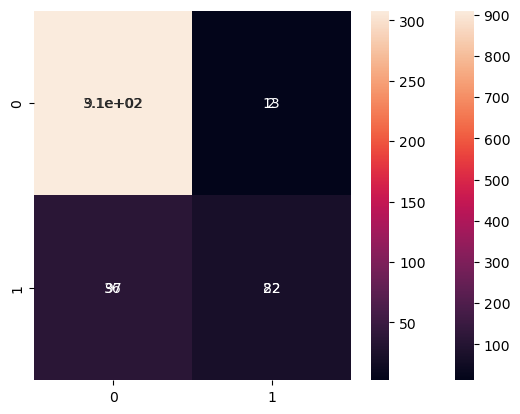

In [52]:
run_AdaBoostClassifier(X_train, X_test, y_train, y_test)

Multonomial NB
Train set
Classification report train set
              precision    recall  f1-score   support

           0       0.84      1.00      0.91       923
           1       1.00      0.01      0.02       179

    accuracy                           0.84      1102
   macro avg       0.92      0.51      0.47      1102
weighted avg       0.87      0.84      0.77      1102


r2 squared error train set: -0.1805927961408329
explained variance score train set: 0.009030547703928749
mean absolute error train set: 0.16061705989110708
mean squared error  train set: 0.16061705989110708
roc-auc score: 0.505586592178771

Confusion matrix train set
Multonomial NB train roc-auc with predict_proba: 0.8037732194628882

Test set
Classification report test set
              precision    recall  f1-score   support

           0       0.84      1.00      0.92       310
           1       1.00      0.02      0.03        58

    accuracy                           0.85       368
   macro avg       0

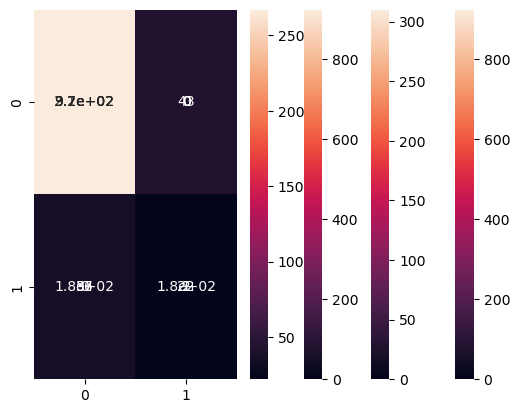

In [53]:
#training the models
run_MultinomialNB(X_train, X_test, y_train, y_test)
run_DecisionTreeClassifier(X_train, X_test, y_train, y_test)

Random forest
Train set
Classification report train set
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       923
           1       1.00      0.92      0.96       179

    accuracy                           0.99      1102
   macro avg       0.99      0.96      0.98      1102
weighted avg       0.99      0.99      0.99      1102


r2 squared error train set: 0.9066197788363183
explained variance score train set: 0.9078060974354939
mean absolute error train set: 0.012704174228675136
mean squared error  train set: 0.012704174228675136
roc-auc score: 0.9608938547486033

Confusion matrix train set
Random forest train roc-auc with predict_proba: 0.9999515788326867

Test set
Classification report test set
              precision    recall  f1-score   support

           0       0.86      0.97      0.91       310
           1       0.53      0.16      0.24        58

    accuracy                           0.85       368
   macro avg       0.6

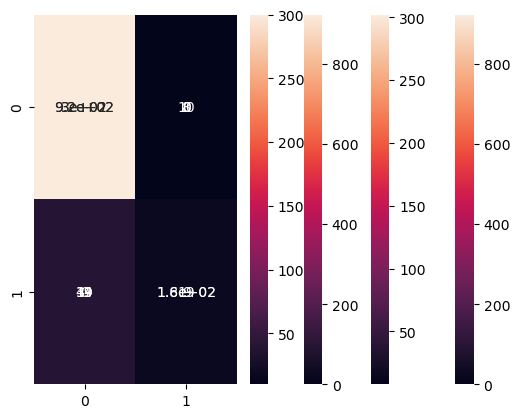

In [54]:
#training the models
run_RandomForestClassifier(X_train, X_test, y_train, y_test)
run_XGboost(X_train, X_test, y_train, y_test)

SVC
Train set
Classification report train set
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       923
           1       0.91      0.39      0.55       179

    accuracy                           0.89      1102
   macro avg       0.90      0.69      0.74      1102
weighted avg       0.90      0.89      0.88      1102


r2 squared error train set: 0.226278167500923
explained variance score train set: 0.289249895591858
mean absolute error train set: 0.10526315789473684
mean squared error  train set: 0.10526315789473684
roc-auc score: 0.691738743591761

Confusion matrix train set
SVC train roc-auc with predict_proba: 0.8561558435269979

Test set
Classification report test set
              precision    recall  f1-score   support

           0       0.90      0.99      0.94       310
           1       0.88      0.40      0.55        58

    accuracy                           0.90       368
   macro avg       0.89      0.69      0.74    

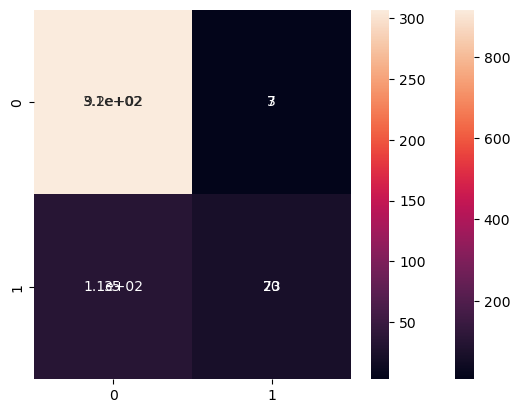

In [55]:
#training the models

run_SVC(X_train, X_test, y_train, y_test)

## Comparing results of models training

In [56]:
data = [
    train_roc_auc,
    test_roc_auc,
    best_accuracy_with_best_parameters
]

In [57]:
results = pd.DataFrame(data)
results 
#I think best one is Multinomial NB because thr gap between train and test accuracy less than 4% 
#and in general it is 83,7%

,Ada boost,Multonomial NB,Decision tree,Random forest,XG Boost,SVC
0,0.913290,0.803773,1.000000,0.999952,1.000000,0.856156
1,0.841769,0.835539,0.620300,0.733120,0.804839,0.873026
2,88.109746,83.756757,83.579853,85.660934,88.113022,88.291564


# Creating ANN

In [58]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Dense(units = 500, activation = 'relu', input_shape = (30,)))
model.add(tf.keras.layers.Dense(units = 500, activation = 'relu'))
model.add(tf.keras.layers.Dense(units = 500, activation = 'relu'))
model.add(tf.keras.layers.Dense(units = 500, activation = 'relu'))
model.add(tf.keras.layers.Dense(units = 500, activation = 'relu'))#новый
model.add(tf.keras.layers.Dense(units = 1, activation = 'sigmoid'))

In [59]:
model.compile(optimizer= 'Adam', loss = 'binary_crossentropy', metrics= ['accuracy'])
#model.compile(optimizer= 'sgd', loss= 'binary_crossentropy', metrics= ['model.compile(optimizer= 'Adam', loss = 'binary_crossentropy', metrics= ['accuracy'])'])
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 500)               15500     
                                                                 
 dense_1 (Dense)             (None, 500)               250500    
                                                                 
 dense_2 (Dense)             (None, 500)               250500    
                                                                 
 dense_3 (Dense)             (None, 500)               250500    
                                                                 
 dense_4 (Dense)             (None, 500)               250500    
                                                                 
 dense_5 (Dense)             (None, 1)                 501       
                                                                 
Total params: 1018001 (3.88 MB)
Trainable params: 101800

In [60]:
epochs_hist = model.fit(X_train, y_train, epochs= 100, batch_size= 10, validation_split= 0.2)

Epoch 1/100
89/89 [==============================] - 2s 8ms/step - loss: 0.3908 - accuracy: 0.8445 - val_loss: 0.3905 - val_accuracy: 0.8416
Epoch 2/100
89/89 [==============================] - 1s 7ms/step - loss: 0.3447 - accuracy: 0.8797 - val_loss: 0.4089 - val_accuracy: 0.8416
Epoch 3/100
89/89 [==============================] - 1s 6ms/step - loss: 0.3104 - accuracy: 0.8751 - val_loss: 0.4459 - val_accuracy: 0.8462
Epoch 4/100
89/89 [==============================] - 1s 7ms/step - loss: 0.2992 - accuracy: 0.8967 - val_loss: 0.3984 - val_accuracy: 0.8462
Epoch 5/100
89/89 [==============================] - 1s 7ms/step - loss: 0.2714 - accuracy: 0.9069 - val_loss: 0.4331 - val_accuracy: 0.8462
Epoch 6/100
89/89 [==============================] - 1s 6ms/step - loss: 0.2402 - accuracy: 0.9092 - val_loss: 0.4032 - val_accuracy: 0.8688
Epoch 7/100
89/89 [==============================] - 1s 6ms/step - loss: 0.2117 - accuracy: 0.9251 - val_loss: 0.4180 - val_accuracy: 0.8281
Epoch 8/100
8

Epoch 58/100
89/89 [==============================] - 1s 7ms/step - loss: 2.0832e-07 - accuracy: 1.0000 - val_loss: 4.6450 - val_accuracy: 0.8643
Epoch 59/100
89/89 [==============================] - 1s 7ms/step - loss: 1.9432e-07 - accuracy: 1.0000 - val_loss: 4.6715 - val_accuracy: 0.8643
Epoch 60/100
89/89 [==============================] - 1s 7ms/step - loss: 1.7899e-07 - accuracy: 1.0000 - val_loss: 4.6958 - val_accuracy: 0.8643
Epoch 61/100
89/89 [==============================] - 1s 7ms/step - loss: 1.6524e-07 - accuracy: 1.0000 - val_loss: 4.7225 - val_accuracy: 0.8643
Epoch 62/100
89/89 [==============================] - 1s 7ms/step - loss: 1.5329e-07 - accuracy: 1.0000 - val_loss: 4.7448 - val_accuracy: 0.8643
Epoch 63/100
89/89 [==============================] - 1s 6ms/step - loss: 1.4311e-07 - accuracy: 1.0000 - val_loss: 4.7673 - val_accuracy: 0.8643
Epoch 64/100
89/89 [==============================] - 1s 6ms/step - loss: 1.3303e-07 - accuracy: 1.0000 - val_loss: 4.7961 -

In [61]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5)

12/12 [==============================] - 0s 1ms/step


In [62]:
y_train_pred = model.predict(X_train)


35/35 [==============================] - 0s 2ms/step


In [63]:
def measure_rmse(actual, predicted):
    return np.sqrt(mean_squared_error(actual,predicted))

In [64]:
measure_rmse(y_train, y_train_pred)

0.16311552868441012

In [65]:
measure_rmse(y_test, y_pred)

0.37227269107703714

In [66]:
r2_score(y_train, y_train_pred)

0.80443142416127

In [67]:
r2_score(y_test, y_pred)

-0.043826473859844395

In [68]:
mean_squared_error(y_train, y_train_pred)

0.026606675697994617

In [69]:
mean_squared_error(y_test, y_pred)

0.13858695652173914

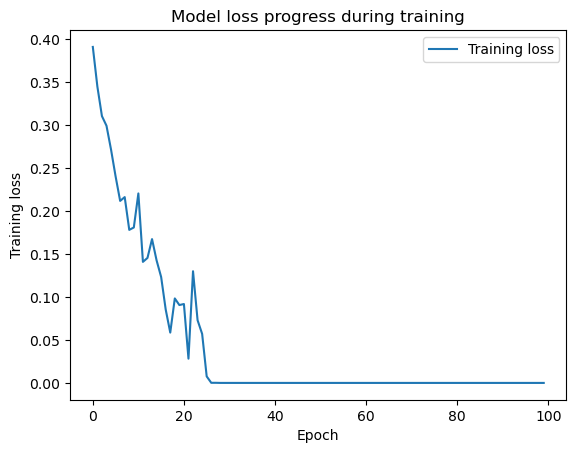

In [70]:
plt.plot(epochs_hist.history['loss'])
plt.title('Model loss progress during training')
plt.xlabel('Epoch')
plt.ylabel('Training loss')
plt.legend(['Training loss'])

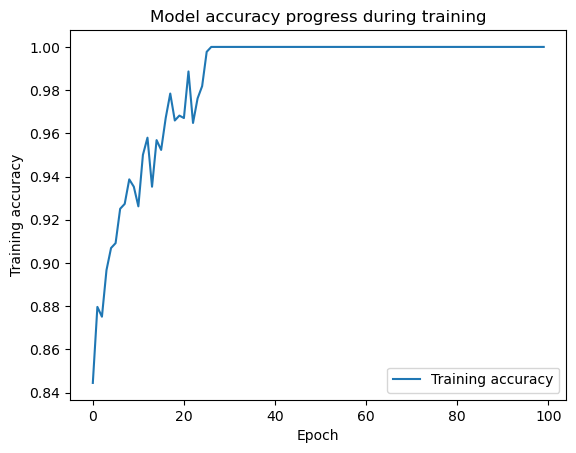

In [71]:
plt.plot(epochs_hist.history['accuracy'])
#plt.plot(epochs_hist.history['mean_squared_error'])
plt.title('Model accuracy progress during training')
plt.xlabel('Epoch')
plt.ylabel('Training accuracy')
plt.legend(['Training accuracy'])

In [72]:
#which means that 40 epochs id enough for training the model

In [73]:
epochs_hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

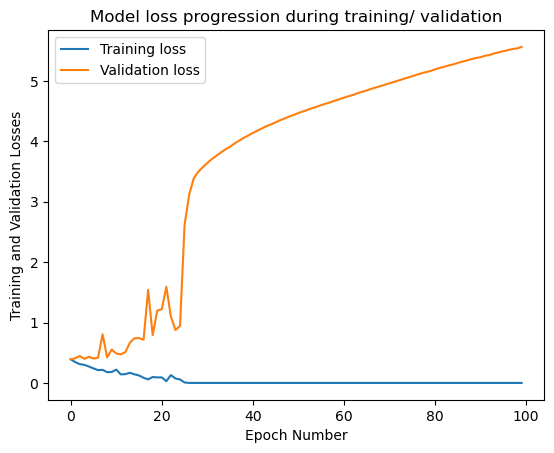

In [74]:
plt.plot(epochs_hist.history['loss'])
plt.plot(epochs_hist.history['val_loss'])
plt.title('Model loss progression during training/ validation')
plt.ylabel('Training and Validation Losses')
plt.xlabel('Epoch Number')
plt.legend(['Training loss','Validation loss'])

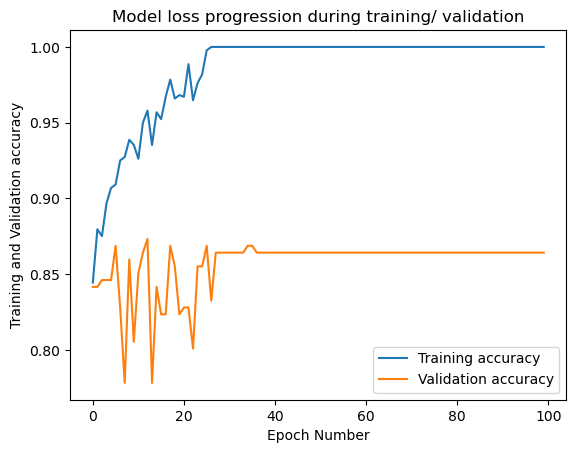

In [75]:
plt.plot(epochs_hist.history['accuracy'])
plt.plot(epochs_hist.history['val_accuracy'])
plt.title('Model loss progression during training/ validation')
plt.ylabel('Training and Validation accuracy')
plt.xlabel('Epoch Number')
plt.legend(['Training accuracy','Validation accuracy'])

In [76]:
#Still means that 40 epochs were enough for training the model because after 40th epoch Validation loss 
#start to increase and Validation accuracy keep being almost stable

<Axes: >

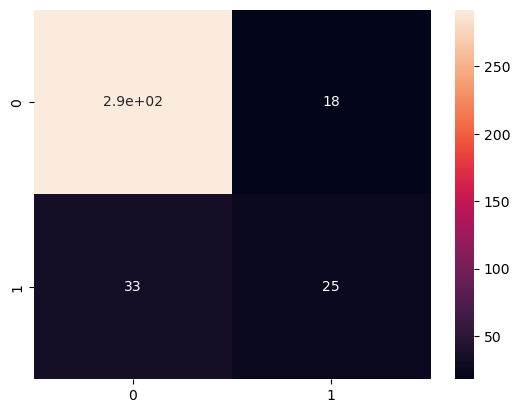

In [77]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot= True)

In [78]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.94      0.92       310
           1       0.58      0.43      0.50        58

    accuracy                           0.86       368
   macro avg       0.74      0.69      0.71       368
weighted avg       0.85      0.86      0.85       368



# Conclusion

Based on the evaluation metrics, 

Multinomial Naive Bayes proved to be the most robust model, achieving an overall accuracy of 83.7% with a minimal gap (under 4%) between training and test sets, confirming excellent generalization. 

For the ANN model, early stopping at 40 epochs was identified as optimal, since training further led to an increase in validation loss while validation accuracy plateaued. 

Furthermore, due to the inherent class imbalance in the dataset, the ANN model exhibited biased performance: it predicts employee retention with 90% precision, but drops to 64% precision when identifying employees likely to quit.